# Slurpini Wine Producer Selection Using Vivino Consumer Data

**Author:** Mahdi Dadgar  
**Project Type:** Business Analytics / Data Science — Data Cleaning, Exploratory Data Analysis, and Scoring Model  
**Domain:** Wine Import / Consumer Review Analytics / Market Selection  
**Business Use Case:** Data-driven pre-selection of promising Italian wine producers for potential collaboration  

## Table of Contents

1. Project Title & Executive Summary  
2. Business Problem  
3. Environment Setup & Libraries  
4. Data Loading & Initial Workbook Inspection  
5. Dataset Understanding  
6. Data Quality Assessment  
7. Data Cleaning & Enhancement  
8. Exploratory Data Analysis  
   - Overall dataset profile  
   - Price outlier policy and impact check  
   - Analytical depth: price, popularity, and rating relationships  
   - Regional analysis  
9. Value-for-Money Analysis  
   - Value metric construction  
   - Sensitivity analysis for metric design choices  
10. Producer and Region Scoring Model  
   - Region opportunity scoring  
   - Scoring robustness check  
   - Producer-candidate shortlist deliverable  
11. Key Insights  
12. Business Recommendations  
13. Limitations and Responsible Use of Data  
14. Final Conclusion  
15. Export Cleaned Project Outputs  

## 1. Project Title & Executive Summary

This project supports Slurpini, an importer of high-quality Italian wines with a strong focus on sustainability, in making more data-driven decisions when selecting potential wine producers for collaboration.

Slurpini regularly receives collaboration requests from wine producers across Italy. Visiting producers in person requires time and resources, so the company needs an objective way to pre-select the most promising producers before making further business decisions.

Using Vivino consumer review data from the Dutch market, this project analyzes wine quality, popularity, price, region, and producer-level performance. The goal is to identify wines, regions, and producers that show strong consumer preference and attractive value for money.

The final outcome is a set of evidence-based recommendations that can help Slurpini prioritize potential producer partnerships in a more structured and commercially informed way.

## 2. Business Problem

Slurpini is an importer of high-quality Italian wines with a strong focus on sustainability. The company receives collaboration requests from wine producers across Italy and needs a more structured way to decide which producers are worth further investigation.

Visiting producers in person requires time, budget, and operational effort. For that reason, Slurpini wants to use available market data to pre-select producers that show strong potential in the Dutch market.

This project uses Vivino consumer review data to evaluate wines, regions, and producers based on quality, popularity, price, and value for money. The main objective is to identify promising producer segments and provide practical recommendations that can support Slurpini’s partnership decisions.

## 3. Environment Setup & Libraries

This section imports the Python libraries required for data loading, cleaning, analysis, and visualization. Additional libraries may be added later if the analysis requires more advanced modelling or statistical methods.

In [1]:
# ============================================================
# 3. Environment Setup & Libraries
# ============================================================

# Core data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Excel workbook inspection
import openpyxl

# Display settings for clearer notebook output
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

# Ignore non-critical warnings for cleaner notebook output
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# Project path setup for Google Colab
# ============================================================

from pathlib import Path
import sys
from google.colab import drive

# Mount Google Drive
drive.mount("/content/drive")

# Set project root manually
PROJECT_ROOT = Path("/content/drive/MyDrive/slurpini-vivino-producer-selection")

# Add project root to Python path so src modules can be imported
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Project root exists:", PROJECT_ROOT.exists())
print("src folder exists:", (PROJECT_ROOT / "src").exists())
print("raw data exists:", (PROJECT_ROOT / "data" / "raw" / "Vivino-export.xlsx").exists())
print("notebook folder exists:", (PROJECT_ROOT / "notebooks").exists())

Mounted at /content/drive
Project root: /content/drive/MyDrive/slurpini-vivino-producer-selection
Project root exists: True
src folder exists: True
raw data exists: True
notebook folder exists: True


In [3]:
# ============================================================
# Import reusable project helper functions
# ============================================================

from src.config import (
    raw_excel_path,
    cleaned_italian_wines_path,
    region_opportunity_scores_path,
    strategic_region_summary_path,
)

from src.vivino_io import (
    parse_vivino_export,
    build_wine_level_dataset,
    filter_italian_wines,
    fix_remaining_text_artifacts,
)

from src.features import (
    add_value_metrics,
    min_max_scale,
    classify_region,
    extract_producer_from_name,
)

print("Project helper modules imported successfully.")
print("Raw data path:", raw_excel_path())

Project helper modules imported successfully.
Raw data path: /content/drive/MyDrive/slurpini-vivino-producer-selection/data/raw/Vivino-export.xlsx


## 4. Data Loading & Initial Workbook Inspection

The dataset for this project is provided as an Excel workbook exported from Vivino. Before cleaning or analysis, the workbook structure must be inspected to understand how the data is stored, how many sheets are available, and whether the data is already in a usable tabular format.

This step helps identify potential data quality issues early, such as unusual sheet structures, missing headers, duplicated records, or values stored in a format that requires parsing.

In [4]:
# ============================================================
# 4. Data Loading & Initial Workbook Inspection
# ============================================================

# Use the raw Excel file from the reproducible project folder
excel_path = raw_excel_path()

print("Excel file path:", excel_path)
print("Excel file exists:", excel_path.exists())

# Load workbook metadata
excel_file = pd.ExcelFile(excel_path)
sheet_names = excel_file.sheet_names

print(f"Number of sheets in the workbook: {len(sheet_names)}")
print("\nSheet names:")
for sheet in sheet_names:
    print(f"- {sheet}")

Excel file path: /content/drive/MyDrive/slurpini-vivino-producer-selection/data/raw/Vivino-export.xlsx
Excel file exists: True
Number of sheets in the workbook: 16

Sheet names:
- Italie
- Uruguay
- VS
- Chili
- Australie
- Spanje
- Argentinie
- Griekenland
- Frankrijk
- Unknown
- Serbia
- Hongarije
- Duitsland
- Libanon
- Portugal
- New Zealand


In [5]:
# Backward-compatible file path variable for older notebook cells
file_path = excel_path

print("file_path set to:", file_path)

file_path set to: /content/drive/MyDrive/slurpini-vivino-producer-selection/data/raw/Vivino-export.xlsx


In [6]:
# Inspect the shape of each sheet
sheet_summary = []

for sheet in sheet_names:
    temp_df = pd.read_excel(file_path, sheet_name=sheet, header=None)
    sheet_summary.append({
        "sheet_name": sheet,
        "rows": temp_df.shape[0],
        "columns": temp_df.shape[1]
    })

sheet_summary_df = pd.DataFrame(sheet_summary)

sheet_summary_df

,sheet_name,rows,columns
0,Italie,5,1
1,Uruguay,51471,1
2,VS,19,1
3,Chili,25902,1
4,Australie,9,1
5,Spanje,35732,1
6,Argentinie,24650,1
7,Griekenland,26441,1
8,Frankrijk,55085,1
9,Unknown,19,1


In [7]:
# Preview the first few rows of each sheet to understand the raw structure
for sheet in sheet_names:
    print(f"\n--- Sheet: {sheet} ---")
    display(pd.read_excel(file_path, sheet_name=sheet, header=None).head())


--- Sheet: Italie ---


,0
0,"name,country,region,rating,rating_count,price"
1,"Tenuta San Guido Sassicaia 2019,""('Itali√´',)""..."
2,"Caiarossa Aria di Caiarossa 2015,""('Itali√´',)..."
3,"Martin Tesch Unplugged Riesling 2019,""('Duitsl..."
4,Azienda Agricola I Luoghi Podere Ritorti Bolgh...



--- Sheet: Uruguay ---


,0
0,"name,country,region,rating,rating_count,price"
1,"Tenuta San Guido Sassicaia 2019,""('Itali√´',)""..."
2,"Caiarossa Aria di Caiarossa 2015,""('Itali√´',)..."
3,"Martin Tesch Unplugged Riesling 2019,""('Duitsl..."
4,Azienda Agricola I Luoghi Podere Ritorti Bolgh...



--- Sheet: VS ---


...

,0
0,"name,country,region,rating,rating_count,price"
1,"Tenuta San Guido Sassicaia 2019,""('Itali√´',)""..."
2,"Caiarossa Aria di Caiarossa 2015,""('Itali√´',)..."
3,"Martin Tesch Unplugged Riesling 2019,""('Duitsl..."
4,Azienda Agricola I Luoghi Podere Ritorti Bolgh...



--- Sheet: Portugal ---


,0
0,"name,country,region,rating,rating_count,price"
1,"Tenuta San Guido Sassicaia 2019,""('Itali√´',)""..."
2,"Caiarossa Aria di Caiarossa 2015,""('Itali√´',)..."
3,"Martin Tesch Unplugged Riesling 2019,""('Duitsl..."
4,Azienda Agricola I Luoghi Podere Ritorti Bolgh...



--- Sheet: New Zealand ---


,0
0,"name,country,region,rating,rating_count,price"
1,"Tenuta San Guido Sassicaia 2019,""('Itali√´',)""..."
2,"Caiarossa Aria di Caiarossa 2015,""('Itali√´',)..."
3,"Martin Tesch Unplugged Riesling 2019,""('Duitsl..."
4,Azienda Agricola I Luoghi Podere Ritorti Bolgh...


## 5. Dataset Understanding

The initial workbook inspection shows that the Vivino data is distributed across multiple Excel sheets. Each sheet contains one raw text column rather than a standard table with separate columns.

The first row in each sheet contains the expected field names: `name`, `country`, `region`, `rating`, `rating_count`, and `price`. The remaining rows contain wine records stored as comma-separated text values.

Before any analysis can be performed, these raw rows need to be parsed into a structured dataset. This step is necessary to make the data suitable for cleaning, exploration, visualization, and producer-level evaluation.

In [8]:
# ============================================================
# 5. Dataset Understanding
# Parse raw workbook sheets into one structured dataframe
# ============================================================

# The reusable parser is defined in src/vivino_io.py.
# It reads all workbook sheets and converts the CSV-like text rows
# into a structured dataframe.

wine_raw, parse_problem_rows = parse_vivino_export(excel_path)

print("Structured dataframe created successfully.")
print(f"Rows parsed successfully: {wine_raw.shape[0]:,}")
print(f"Columns: {wine_raw.shape[1]}")
print(f"Problem rows: {len(parse_problem_rows):,}")

display(wine_raw.head())

Structured dataframe created successfully.
Rows parsed successfully: 409,777
Columns: 7
Problem rows: 0


,name,country,region,rating,rating_count,price,source_sheet
0,Tenuta San Guido Sassicaia 2019,"('Itali√´',)","('Bolgheri Sassicaia',)",4.60,1006,323.80,Italie
1,Caiarossa Aria di Caiarossa 2015,"('Itali√´',)","('Toscane',)",4.20,506,28.05,Italie
2,Martin Tesch Unplugged Riesling 2019,"('Duitsland',)","('Nahe',)",3.70,129,10.29,Italie
3,Azienda Agricola I Luoghi Podere Ritorti Bolgh...,"('Itali√´',)","('Bolgheri Superiore',)",4.20,63,28.70,Italie
4,Tenuta San Guido Sassicaia 2019,"('Itali√´',)","('Bolgheri Sassicaia',)",4.60,983,324.27,Uruguay


In [9]:
# Display the structure of the parsed dataset
wine_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 409777 entries, 0 to 409776
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   name          409777 non-null  object 
 1   country       409777 non-null  object 
 2   region        409777 non-null  object 
 3   rating        409777 non-null  float64
 4   rating_count  409777 non-null  int64  
 5   price         409777 non-null  float64
 6   source_sheet  409777 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 21.9+ MB


In [10]:
# Preview random rows to check whether parsing worked correctly
wine_raw.sample(10, random_state=42)

,name,country,region,rating,rating_count,price,source_sheet
145967,Achaval-Ferrer Finca Mirador Malbec 2014,"('Argentini√´',)","('Maipu',)",4.40,782,999.00,Griekenland
281299,Clos de l'Oratoire Saint-√âmilion Grand Cru (G...,"('Frankrijk',)","('Grand cru Saint-√âmilion',)",4.20,453,52.50,Hongarije
57991,Mas des Bressades Cuv√©e Tradition Costi√®res ...,"('Frankrijk',)","('Costi√®res-de-N√Æmes',)",3.60,109,28.99,Chili
70963,Ceretto Barolo Brunate 2006,"('Itali√´',)","('Barolo',)",4.30,453,90.00,Chili
107793,Domaine de la Janasse Ch√¢teauneuf-du-Pape Cha...,"('Frankrijk',)","('Ch√¢teauneuf-du-Pape',)",4.10,435,65.00,Spanje
405893,Donnafugata Ben Ry√© Passito di Pantelleria 2020,"('Itali√´',)","('Passito di Pantelleria',)",4.40,455,60.00,New Zealand
229447,Alamos Cabernet Sauvignon 2019,"('Argentini√´',)","('Mendoza',)",3.80,2423,21.99,Serbia
388634,Yves Cuilleron Viognier Les Vignes d'√† C√¥t√©...,"('Frankrijk',)","('Collines Rhodaniennes',)",4.00,108,51.99,New Zealand
204741,Laurent-Perrier Alexandra Champagne Ros√© (Gra...,"('Frankrijk',)","('Champagne',)",4.60,849,345.00,Frankrijk
30523,Paul Jaboulet A√Æn√© Crozes-Hermitage Domaine ...,"('Frankrijk',)","('Crozes-Hermitage',)",4.00,435,29.30,Uruguay


### Initial Dataset Structure Findings

The raw Vivino workbook was successfully parsed into a structured dataframe containing 409,777 rows and 7 columns.

The parsed dataset includes the following fields:

- `name`: wine name and vintage information
- `country`: country of origin
- `region`: wine region
- `rating`: average Vivino consumer rating
- `rating_count`: number of consumer ratings
- `price`: listed wine price
- `source_sheet`: original Excel sheet name

The `source_sheet` column was added during parsing to support data quality checks. It should not automatically be interpreted as the wine's country of origin, because the preview already shows that wines from different countries can appear in multiple sheets.

Several data quality issues are visible at this stage, including text encoding problems, tuple-like country and region values, and likely duplicate wine records across sheets. These issues will be addressed before performing the main analysis.

In [11]:
# ============================================================
# 5. Dataset Understanding
# Basic uniqueness and duplicate checks
# ============================================================

print("Dataset shape:")
print(f"Rows: {wine_raw.shape[0]:,}")
print(f"Columns: {wine_raw.shape[1]}")

print("\nUnique value counts:")
print(f"Unique wine names: {wine_raw['name'].nunique():,}")
print(f"Unique countries: {wine_raw['country'].nunique():,}")
print(f"Unique regions: {wine_raw['region'].nunique():,}")
print(f"Unique source sheets: {wine_raw['source_sheet'].nunique():,}")

print("\nExact duplicate rows:")
print(f"{wine_raw.duplicated().sum():,}")

Dataset shape:
Rows: 409,777
Columns: 7

Unique value counts:
Unique wine names: 14,088
Unique countries: 35
Unique regions: 753
Unique source sheets: 16

Exact duplicate rows:
222,522


In [12]:
# Inspect raw country values before cleaning
wine_raw["country"].value_counts().head(20)

,count
country,
"('Frankrijk',)",192868
"('Itali√´',)",77382
"('Spanje',)",35607
"('Australi√´',)",31138
"('Portugal',)",15415
"('Verenigde Staten',)",13154
"('Argentini√´',)",12099
"('Chili',)",11512
"('Duitsland',)",4718


In [13]:
# Inspect raw region values before cleaning
wine_raw["region"].value_counts().head(20)

,count
region,
"('Grand cru Saint-√âmilion',)",20878
"('Champagne',)",19529
"('Pauillac',)",15857
"('Margaux',)",13952
"('Saint-Est√®phe',)",12406
"('Rioja',)",10602
"('Barolo',)",9162
"('Zuid-Australi√´',)",8664
"('Haut-M√©doc',)",7828


In [14]:
# Check how often the same wine name appears in the parsed dataset
wine_name_frequency = (
    wine_raw["name"]
    .value_counts()
    .reset_index()
)

wine_name_frequency.columns = ["name", "row_count"]

wine_name_frequency.head(20)

,name,row_count
0,Ch√¢teau Grand Mayne Saint-√âmilion Grand Cru ...,4436
1,Donnafugata Ben Ry√© Passito di Pantelleria 2020,4436
2,Ch√¢teau Latour Grand Vin Pauillac (Premier Gr...,4427
3,Zonin Montepulciano D'Abruzzo 2020,4426
4,Gaja Sito Moresco Langhe 2020,4424
5,Ch√¢teau Mouton Rothschild Le Petit Mouton de ...,4424
6,N¬∞1 de Dourthe Sauvignon Blanc Bordeaux 2015,4421
7,Paul Jaboulet A√Æn√© Hermitage La Chapelle Rou...,4421
8,Ch√¢teau Clement-Pichon Haut-M√©doc 2015,4421
9,Ceretto Barolo Brunate 2006,4421


In [15]:
# Inspect records for one repeated wine to understand why duplicates exist
wine_raw[wine_raw["name"] == wine_name_frequency.loc[0, "name"]].head(20)

,name,country,region,rating,rating_count,price,source_sheet
8630,Ch√¢teau Grand Mayne Saint-√âmilion Grand Cru ...,"('Frankrijk',)","('Grand cru Saint-√âmilion',)",4.20,454,796.00,Uruguay
15196,Ch√¢teau Grand Mayne Saint-√âmilion Grand Cru ...,"('Frankrijk',)","('Grand cru Saint-√âmilion',)",4.20,454,35.00,Uruguay
15221,Ch√¢teau Grand Mayne Saint-√âmilion Grand Cru ...,"('Frankrijk',)","('Grand cru Saint-√âmilion',)",4.20,454,35.00,Uruguay
15246,Ch√¢teau Grand Mayne Saint-√âmilion Grand Cru ...,"('Frankrijk',)","('Grand cru Saint-√âmilion',)",4.20,454,35.00,Uruguay
15270,Ch√¢teau Grand Mayne Saint-√âmilion Grand Cru ...,"('Frankrijk',)","('Grand cru Saint-√âmilion',)",4.20,454,35.00,Uruguay
15296,Ch√¢teau Grand Mayne Saint-√âmilion Grand Cru ...,"('Frankrijk',)","('Grand cru Saint-√âmilion',)",4.20,454,35.00,Uruguay
15321,Ch√¢teau Grand Mayne Saint-√âmilion Grand Cru ...,"('Frankrijk',)","('Grand cru Saint-√âmilion',)",4.20,454,35.00,Uruguay
15346,Ch√¢teau Grand Mayne Saint-√âmilion Grand Cru ...,"('Frankrijk',)","('Grand cru Saint-√âmilion',)",4.20,454,35.00,Uruguay
15371,Ch√¢teau Grand Mayne Saint-√âmilion Grand Cru ...,"('Frankrijk',)","('Grand cru Saint-√âmilion',)",4.20,454,35.00,Uruguay
15396,Ch√¢teau Grand Mayne Saint-√âmilion Grand Cru ...,"('Frankrijk',)","('Grand cru Saint-√âmilion',)",4.20,454,35.00,Uruguay


## 6. Data Quality Assessment

Before cleaning the dataset, several data quality checks were performed to understand whether the parsed data is suitable for analysis.

The initial inspection shows that the dataset contains a large number of duplicated records. Although the parsed dataframe contains more than 400,000 rows, the number of unique wine names is much smaller. This suggests that the crawler collected repeated observations across sheets or repeated the same wine records multiple times.

Several additional quality issues are also visible:

- Country and region values are stored as tuple-like strings, for example ('Frankrijk',).
- Some text values contain encoding issues, such as corrupted accents in country, region, or wine names.
- The original Excel sheet name does not always represent the actual wine country.
- Some wines appear many times, sometimes with identical values and sometimes with different prices.

These issues need to be handled carefully before performing analysis, because duplicated records could distort rankings, popularity measures, and producer or region-level recommendations.

### 6.1 Formal Data Quality Control Log

To make the cleaning process more transparent and defensible, this section summarizes the main data quality checks before cleaning.

The goal is to document what was checked, what issue was found, what action is required, and how each issue may affect the analysis.

In [16]:
# ============================================================
# 6.1 Formal Data Quality Control Log
# ============================================================

# Basic quality checks on the parsed raw dataset
total_rows = len(wine_raw)
total_columns = wine_raw.shape[1]

parse_failure_count = len(parse_problem_rows)
exact_duplicate_count = wine_raw.duplicated().sum()

missing_value_count = wine_raw.isna().sum().sum()

non_positive_price_count = (wine_raw["price"] <= 0).sum()
invalid_rating_count = ((wine_raw["rating"] < 0) | (wine_raw["rating"] > 5)).sum()
non_positive_rating_count_count = (wine_raw["rating_count"] <= 0).sum()

# Check for common visible encoding artifacts before text cleanup
encoding_patterns = ["√", "¬", "Ã", "Â", "‚Ä"]
text_columns = ["name", "country", "region"]

# Count text-field occurrences with visible encoding artifacts
encoding_artifact_field_occurrences = 0

for col in text_columns:
    encoding_artifact_field_occurrences += wine_raw[col].astype(str).apply(
        lambda x: any(pattern in x for pattern in encoding_patterns)
    ).sum()

# Count unique rows where at least one text column contains a visible encoding artifact
encoding_artifact_row_count = wine_raw[text_columns].astype(str).apply(
    lambda row: any(
        any(pattern in value for pattern in encoding_patterns)
        for value in row
    ),
    axis=1
).sum()

data_quality_log = pd.DataFrame({
    "quality_check": [
        "Total parsed rows",
        "Total columns",
        "Parse failures",
        "Exact duplicate rows",
        "Missing values",
        "Non-positive prices",
        "Invalid ratings outside 0-5 range",
        "Non-positive rating counts",
        "Rows with at least one visible encoding artifact",
        "Text-field occurrences with visible encoding artifacts"
    ],
    "result": [
        total_rows,
        total_columns,
        parse_failure_count,
        exact_duplicate_count,
        missing_value_count,
        non_positive_price_count,
        invalid_rating_count,
        non_positive_rating_count_count,
        encoding_artifact_row_count,
        encoding_artifact_field_occurrences
    ],
    "planned_action": [
        "Use as raw parsed dataset",
        "Confirm expected schema",
        "Review and report if present",
        "Remove exact duplicates before analysis",
        "Investigate if present",
        "Exclude or correct before value metrics",
        "Investigate if present",
        "Investigate if present",
        "Clean recurring text encoding issues",
        "Clean recurring text encoding issues"
    ],
    "potential_impact": [
        "Defines the starting analytical dataset",
        "Confirms the parser created the expected structure",
        "Could indicate data loss or parsing bias",
        "Could over-count wines and distort popularity",
        "Could affect summaries or model inputs",
        "Could distort value-for-money calculations",
        "Could distort quality analysis",
        "Could distort popularity/reliability analysis",
        "Could split identical countries/regions into separate labels",
        "Shows how widespread encoding issues are across text fields"
    ]
})

display(data_quality_log)

# Optional parse failure preview
if parse_failure_count > 0:
    print("\nExample parse failures:")
    display(parse_problem_rows.head())
else:
    print("\nNo parse failures detected.")

,quality_check,result,planned_action,potential_impact
0,Total parsed rows,409777,Use as raw parsed dataset,Defines the starting analytical dataset
1,Total columns,7,Confirm expected schema,Confirms the parser created the expected struc...
2,Parse failures,0,Review and report if present,Could indicate data loss or parsing bias
3,Exact duplicate rows,222522,Remove exact duplicates before analysis,Could over-count wines and distort popularity
4,Missing values,0,Investigate if present,Could affect summaries or model inputs
5,Non-positive prices,0,Exclude or correct before value metrics,Could distort value-for-money calculations
6,Invalid ratings outside 0-5 range,0,Investigate if present,Could distort quality analysis
7,Non-positive rating counts,0,Investigate if present,Could distort popularity/reliability analysis
8,Rows with at least one visible encoding artifact,322736,Clean recurring text encoding issues,Could split identical countries/regions into s...
9,Text-field occurrences with visible encoding a...,427943,Clean recurring text encoding issues,Shows how widespread encoding issues are acros...



No parse failures detected.


### Data Quality Interpretation

The quality control log shows that the workbook was parsed successfully into a structured dataset, with no parse failures detected.

The main data quality issue is the high number of exact duplicate rows. If left untreated, these duplicates could distort popularity, regional representation, and downstream scoring.

The log also shows visible text encoding artifacts in the raw text fields. This confirms the need for text cleaning before grouping countries, regions, and wines. The notebook reports both row-level encoding issues and text-field-level occurrences, because one row can contain artifacts in more than one text column.

Since the value-for-money analysis depends on price, rating, and rating count, checks for invalid prices, ratings, and rating counts are included before metric construction.

In [17]:
# ============================================================
# 6. Data Quality Assessment
# Duplicate impact summary
# ============================================================

total_rows = len(wine_raw)
exact_duplicates = wine_raw.duplicated().sum()
unique_rows = total_rows - exact_duplicates

duplicate_summary = pd.DataFrame({
    "metric": [
        "Total parsed rows",
        "Exact duplicate rows",
        "Rows after removing exact duplicates",
        "Duplicate share (%)"
    ],
    "value": [
        total_rows,
        exact_duplicates,
        unique_rows,
        round((exact_duplicates / total_rows) * 100, 2)
    ]
})

duplicate_summary

,metric,value
0,Total parsed rows,"409,777.00"
1,Exact duplicate rows,"222,522.00"
2,Rows after removing exact duplicates,"187,255.00"
3,Duplicate share (%),54.30


In [18]:
# Create a working copy by removing exact duplicate rows
wine_df = wine_raw.drop_duplicates().copy()

print("Working dataframe created after removing exact duplicate rows.")
print(f"Original rows: {wine_raw.shape[0]:,}")
print(f"Rows after exact duplicate removal: {wine_df.shape[0]:,}")
print(f"Rows removed: {wine_raw.shape[0] - wine_df.shape[0]:,}")

Working dataframe created after removing exact duplicate rows.
Original rows: 409,777
Rows after exact duplicate removal: 187,255
Rows removed: 222,522


In [19]:
# Check repeated wine names after removing exact duplicates
remaining_name_frequency = (
    wine_df["name"]
    .value_counts()
    .reset_index()
)

remaining_name_frequency.columns = ["name", "row_count"]

remaining_name_frequency.head(20)

,name,row_count
0,Mo√´t & Chandon Imp√©rial Brut Champagne N.V.,341
1,Veuve Clicquot Brut (Carte Jaune) Champagne N.V.,281
2,Bollinger Special Cuv√©e Brut A√ø Champagne N.V.,268
3,Perrier-Jou√´t Grand Brut Champagne N.V.,222
4,Laurent-Perrier La Cuv√©e Brut Champagne N.V.,217
5,Billecart-Salmon Brut R√©serve Champagne N.V.,217
6,Freixenet Cava Cord√≥n Negro Brut N.V.,207
7,Pol Roger R√©serve Brut Champagne N.V.,207
8,Laurent-Perrier Brut Cuv√©e Champagne Ros√© N.V.,205
9,Billecart-Salmon Brut Ros√© Champagne N.V.,202


In [20]:
# Inspect the most frequently repeated wine after exact duplicate removal
most_repeated_wine = remaining_name_frequency.loc[0, "name"]

wine_df[wine_df["name"] == most_repeated_wine].sort_values(
    by=["country", "region", "rating", "rating_count", "price", "source_sheet"]
).head(30)

,name,country,region,rating,rating_count,price,source_sheet
113191,Mo√´t & Chandon Imp√©rial Brut Champagne N.V.,"('Frankrijk',)","('Champagne',)",4.10,114119,36.98,Argentinie
51551,Mo√´t & Chandon Imp√©rial Brut Champagne N.V.,"('Frankrijk',)","('Champagne',)",4.10,114119,36.98,Chili
281677,Mo√´t & Chandon Imp√©rial Brut Champagne N.V.,"('Frankrijk',)","('Champagne',)",4.10,114119,36.98,Duitsland
164280,Mo√´t & Chandon Imp√©rial Brut Champagne N.V.,"('Frankrijk',)","('Champagne',)",4.10,114119,36.98,Frankrijk
137840,Mo√´t & Chandon Imp√©rial Brut Champagne N.V.,"('Frankrijk',)","('Champagne',)",4.10,114119,36.98,Griekenland
257012,Mo√´t & Chandon Imp√©rial Brut Champagne N.V.,"('Frankrijk',)","('Champagne',)",4.10,114119,36.98,Hongarije
306764,Mo√´t & Chandon Imp√©rial Brut Champagne N.V.,"('Frankrijk',)","('Champagne',)",4.10,114119,36.98,Libanon
383314,Mo√´t & Chandon Imp√©rial Brut Champagne N.V.,"('Frankrijk',)","('Champagne',)",4.10,114119,36.98,New Zealand
333606,Mo√´t & Chandon Imp√©rial Brut Champagne N.V.,"('Frankrijk',)","('Champagne',)",4.10,114119,36.98,Portugal
219382,Mo√´t & Chandon Imp√©rial Brut Champagne N.V.,"('Frankrijk',)","('Champagne',)",4.10,114119,36.98,Serbia


### Duplicate Assessment Findings

The duplicate check confirms that a substantial part of the parsed dataset consists of exact duplicate rows. These records were removed to avoid over-counting the same wine observations during analysis.

Only exact duplicates were removed at this stage. Wines with the same name but different prices were kept for further inspection, because price differences may represent variation across offers, vintages, sellers, or crawler observations. Removing them too early could lead to loss of useful pricing information.

The deduplicated dataframe will be used as the working dataset for the next cleaning steps.

## 7. Data Cleaning & Enhancement

The parsed dataset still contains several issues that need to be cleaned before analysis. The main issues are tuple-like text values in the country and region columns, corrupted character encoding in some text fields, and repeated wine observations across multiple source sheets.

The cleaning process focuses on creating a reliable working dataset for analysis while preserving the logic of the original data. Exact duplicate rows have already been removed. The next steps clean text fields, standardize key columns, and create a wine-level dataset where each wine appears once with summarized price information.

### 7.1 Reproducible Cleaning Pipeline

This section converts the parsed raw dataset into a cleaned wine-level dataset.

The cleaning workflow removes exact duplicate rows, standardizes country and region text, fixes visible encoding issues, and aggregates repeated observations into one row per wine-country-region combination.

For portfolio reproducibility, the core cleaning logic is stored in `src/vivino_io.py` and imported into the notebook.

In [21]:
# ============================================================
# 7.1 Reproducible Cleaning Pipeline
# ============================================================

# Build the cleaned wine-level dataset using the reusable helper function.
# This function:
# 1. removes exact duplicate rows
# 2. cleans tuple-like country and region values
# 3. aggregates repeated observations to wine level
# 4. applies first-pass text encoding cleanup

wine_level = build_wine_level_dataset(wine_raw)

print("Wine-level dataset created successfully.")
print(f"Rows before wine-level aggregation: {wine_raw.drop_duplicates().shape[0]:,}")
print(f"Rows after wine-level aggregation: {wine_level.shape[0]:,}")
print(f"Columns: {wine_level.shape[1]}")

display(wine_level.head())

Wine-level dataset created successfully.
Rows before wine-level aggregation: 187,255
Rows after wine-level aggregation: 14,088
Columns: 10


,name,country_clean,region_clean,rating,rating_count,min_price,median_price,max_price,price_observations,source_sheet_count
0,1000 Stories Zinfandel 2018,Verenigde Staten,Californië,4.10,12833,16.50,16.50,16.50,12,12
1,1000 Stories Zinfandel 2020,Verenigde Staten,Californië,4.10,3485,13.99,29.99,29.99,13,12
2,14 Hands Cabernet Sauvignon 2018,Verenigde Staten,Columbia Valley,3.80,1807,26.49,26.49,26.49,12,12
3,19 Crimes Cabernet Sauvignon 2019,Australië,Victoria,3.80,4106,7.71,11.90,12.45,31,12
4,19 Crimes Cabernet Sauvignon 2020,Australië,Victoria,3.70,1802,10.90,12.30,220.00,43,12


In [22]:
# Validate whether each wine-level record is unique by name, country, and region
wine_level_duplicate_check = wine_level.duplicated(
    subset=["name", "country_clean", "region_clean"]
).sum()

print("Duplicate wine-level records after aggregation:", wine_level_duplicate_check)

Duplicate wine-level records after aggregation: 0


### Cleaning Result

After correcting common encoding issues, country and region labels are more readable and suitable for analysis. This step is especially important because the project will rely on country-level and region-level comparisons, and unclear labels would reduce the quality of the final visualizations and recommendations.

### 7.2 Italian Wine Subset and Final Text Cleanup

In [23]:
# ============================================================
# 7.2 Italian Wine Subset and Final Text Cleanup
# ============================================================

# Filter the wine-level dataset to Italian wines
italian_wines = filter_italian_wines(wine_level)

# Apply second-pass cleanup to remaining visible text artifacts
for col in ["name", "country_clean", "region_clean"]:
    italian_wines[col] = italian_wines[col].apply(fix_remaining_text_artifacts)

# Check remaining visible encoding artifacts after cleanup
encoding_patterns = ["√", "¬", "Ã", "Â", "‚Ä"]
text_columns = ["name", "country_clean", "region_clean"]

remaining_encoding_artifacts = italian_wines[text_columns].astype(str).apply(
    lambda row: any(
        any(pattern in value for pattern in encoding_patterns)
        for value in row
    ),
    axis=1
).sum()

print("Italian wine subset created successfully.")
print(f"Italian wine records: {italian_wines.shape[0]:,}")
print(f"Italian regions: {italian_wines['region_clean'].nunique():,}")
print(f"Remaining visible encoding-artifact rows: {remaining_encoding_artifacts:,}")

display(italian_wines.head())

Italian wine subset created successfully.
Italian wine records: 2,986
Italian regions: 179
Remaining visible encoding-artifact rows: 0


,name,country_clean,region_clean,rating,rating_count,min_price,median_price,max_price,price_observations,source_sheet_count
0,47 Anno Domini Le Argille Cabernet di Cabernet...,Italië,Veneto,4.30,570,28.99,28.99,28.99,3,3
1,ARPEPE Il Pettirosso 2017,Italië,Valtellina Superiore,4.00,492,93.38,93.38,93.38,12,12
2,ARPEPE Inferno Sesto Canto Riserva Valtellina ...,Italië,Valtellina Superiore,4.20,126,180.00,180.00,180.00,12,12
3,ARPEPE Rosso di Valtellina 2016,Italië,Valtellina,3.80,1429,37.00,37.00,37.00,1,1
4,ARPEPE Rosso di Valtellina 2020,Italië,Valtellina,3.80,536,66.00,66.00,66.00,12,12


In [24]:
# Inspect the structure of the Italian wine dataset
italian_wines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2986 entries, 0 to 2985
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                2986 non-null   object 
 1   country_clean       2986 non-null   object 
 2   region_clean        2986 non-null   object 
 3   rating              2986 non-null   float64
 4   rating_count        2986 non-null   int64  
 5   min_price           2986 non-null   float64
 6   median_price        2986 non-null   float64
 7   max_price           2986 non-null   float64
 8   price_observations  2986 non-null   int64  
 9   source_sheet_count  2986 non-null   int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 233.4+ KB


In [25]:
# Summary statistics for the main numeric fields
italian_wines[["rating", "rating_count", "min_price", "median_price", "max_price", "price_observations", "source_sheet_count"]].describe()

,rating,rating_count,min_price,median_price,max_price,price_observations,source_sheet_count
count,"2,986.00","2,986.00","2,986.00","2,986.00","2,986.00","2,986.00","2,986.00"
mean,4.00,"1,690.88",158.29,179.71,253.54,13.67,8.55
std,0.28,"2,878.89",224.42,234.00,278.22,15.88,4.26
min,3.00,41.00,3.27,3.27,3.27,1.00,1.00
25%,3.80,491.00,25.92,34.33,48.00,5.00,4.25
50%,4.00,948.00,59.83,75.00,121.00,12.00,12.00
75%,4.20,"1,927.75",175.00,218.25,396.85,12.00,12.00
max,4.80,"66,173.00","1,955.00","1,955.00","1,955.00",188.00,16.00


In [26]:
# Top Italian regions by number of wines in the dataset
italian_wines["region_clean"].value_counts().head(25)

,count
region_clean,
Toscane,332
Barolo,200
Brunello di Montalcino,194
Chianti Classico,185
Terre Siciliane,98
Prosecco,81
Veneto,67
Puglia,67
Montepulciano d'Abruzzo,60


In [27]:
# Check for missing values in the Italian wine dataset
italian_wines.isna().sum()

,0
name,0
country_clean,0
region_clean,0
rating,0
rating_count,0
min_price,0
median_price,0
max_price,0
price_observations,0
source_sheet_count,0


### Italian Wine Dataset

After cleaning and aggregation, the project creates a focused Italian wine dataset for the main analysis. This subset is aligned with Slurpini's business goal of identifying promising Italian producers and regions for potential collaboration.

The Italian subset will be used for the main exploratory analysis, `value-for-money evaluation` and `producer or region scoring model`.

In [28]:
# Reset index after filtering and cleaning for cleaner downstream analysis
italian_wines = italian_wines.reset_index(drop=True)

print("Italian wine dataset prepared for analysis.")
print(f"Final rows: {italian_wines.shape[0]:,}")
print(f"Final columns: {italian_wines.shape[1]}")

italian_wines.head()

Italian wine dataset prepared for analysis.
Final rows: 2,986
Final columns: 10


,name,country_clean,region_clean,rating,rating_count,min_price,median_price,max_price,price_observations,source_sheet_count
0,47 Anno Domini Le Argille Cabernet di Cabernet...,Italië,Veneto,4.30,570,28.99,28.99,28.99,3,3
1,ARPEPE Il Pettirosso 2017,Italië,Valtellina Superiore,4.00,492,93.38,93.38,93.38,12,12
2,ARPEPE Inferno Sesto Canto Riserva Valtellina ...,Italië,Valtellina Superiore,4.20,126,180.00,180.00,180.00,12,12
3,ARPEPE Rosso di Valtellina 2016,Italië,Valtellina,3.80,1429,37.00,37.00,37.00,1,1
4,ARPEPE Rosso di Valtellina 2020,Italië,Valtellina,3.80,536,66.00,66.00,66.00,12,12


## 8. Exploratory Data Analysis (EDA)

This section explores the cleaned Italian wine dataset to understand the main patterns in consumer ratings, popularity, prices, and regional representation.

The exploratory analysis is guided by Slurpini's business objective: identifying promising Italian wines, regions, and producer opportunities based on objective market indicators from Vivino data.

The analysis focuses on four core dimensions:

- **Quality:** measured by average consumer rating
- **Popularity:** measured by number of ratings
- **Price level:** measured by median listed price
- **Regional representation:** measured by the number of wines per Italian region

In [29]:
# ============================================================
# 8. Exploratory Data Analysis
# Overall dataset profile
# ============================================================

eda_summary = pd.DataFrame({
    "metric": [
        "Number of Italian wines",
        "Number of Italian regions",
        "Average rating",
        "Median rating",
        "Average rating count",
        "Median rating count",
        "Average median price",
        "Median median price",
        "Minimum median price",
        "Maximum median price"
    ],
    "value": [
        italian_wines.shape[0],
        italian_wines["region_clean"].nunique(),
        round(italian_wines["rating"].mean(), 2),
        round(italian_wines["rating"].median(), 2),
        round(italian_wines["rating_count"].mean(), 2),
        round(italian_wines["rating_count"].median(), 2),
        round(italian_wines["median_price"].mean(), 2),
        round(italian_wines["median_price"].median(), 2),
        round(italian_wines["median_price"].min(), 2),
        round(italian_wines["median_price"].max(), 2)
    ]
})

eda_summary

,metric,value
0,Number of Italian wines,"2,986.00"
1,Number of Italian regions,179.00
2,Average rating,4.00
3,Median rating,4.00
4,Average rating count,"1,690.88"
5,Median rating count,948.00
6,Average median price,179.71
7,Median median price,75.00
8,Minimum median price,3.27
9,Maximum median price,"1,955.00"


### Overall Dataset Profile

The Italian wine subset provides a focused basis for Slurpini's analysis. It contains wine-level observations with consumer rating, popularity, price, and region information.

This profile gives a first view of the market represented in the dataset and helps define the scale of the analysis before moving into regional and wine-level comparisons.

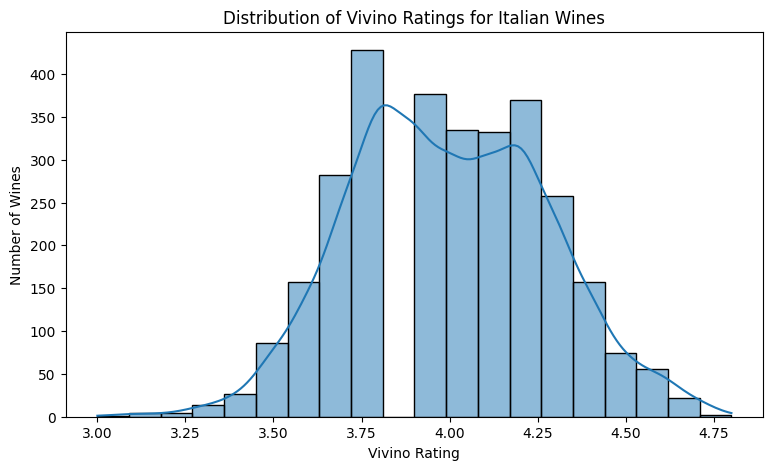

In [30]:
# Distribution of Italian wine ratings
plt.figure(figsize=(9, 5))
sns.histplot(italian_wines["rating"], bins=20, kde=True)

plt.title("Distribution of Vivino Ratings for Italian Wines")
plt.xlabel("Vivino Rating")
plt.ylabel("Number of Wines")
plt.show()

In [31]:
# Rating summary by quantiles
rating_quantiles = italian_wines["rating"].quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 1]).reset_index()
rating_quantiles.columns = ["quantile", "rating"]

rating_quantiles

,quantile,rating
0,0.00,3.00
1,0.25,3.80
2,0.50,4.00
3,0.75,4.20
4,0.90,4.40
5,0.95,4.50
6,1.00,4.80


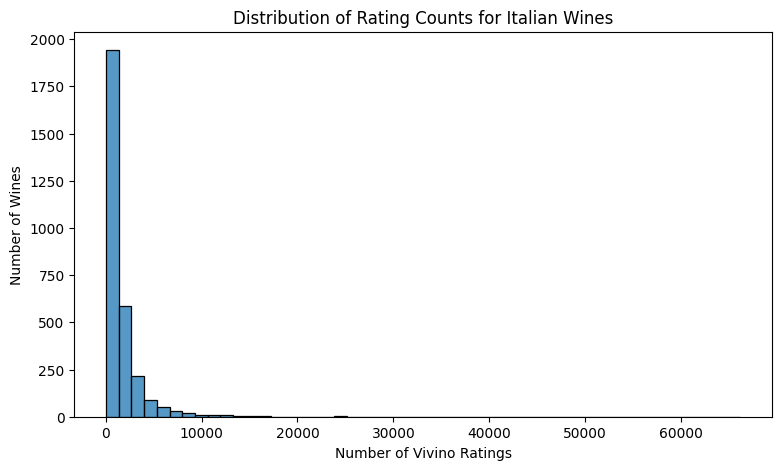

In [32]:
# Distribution of rating counts
plt.figure(figsize=(9, 5))
sns.histplot(italian_wines["rating_count"], bins=50)

plt.title("Distribution of Rating Counts for Italian Wines")
plt.xlabel("Number of Vivino Ratings")
plt.ylabel("Number of Wines")
plt.show()

In [33]:
# Because rating_count is usually highly skewed, inspect quantiles
rating_count_quantiles = italian_wines["rating_count"].quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]).reset_index()
rating_count_quantiles.columns = ["quantile", "rating_count"]

rating_count_quantiles

,quantile,rating_count
0,0.00,41.00
1,0.25,491.00
2,0.50,948.00
3,0.75,"1,927.75"
4,0.90,"3,598.00"
5,0.95,"5,452.50"
6,0.99,"11,750.40"
7,1.00,"66,173.00"


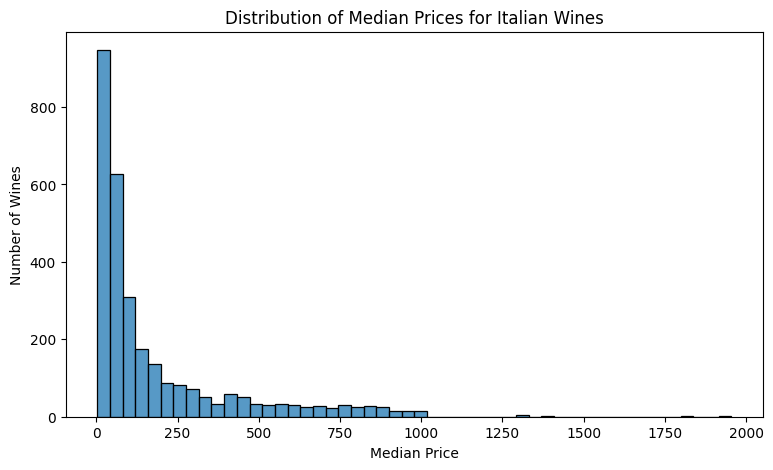

In [34]:
# Distribution of median prices
plt.figure(figsize=(9, 5))
sns.histplot(italian_wines["median_price"], bins=50)

plt.title("Distribution of Median Prices for Italian Wines")
plt.xlabel("Median Price")
plt.ylabel("Number of Wines")
plt.show()

In [35]:
# Price quantiles
price_quantiles = italian_wines["median_price"].quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]).reset_index()
price_quantiles.columns = ["quantile", "median_price"]

price_quantiles

,quantile,median_price
0,0.00,3.27
1,0.25,34.33
2,0.50,75.00
3,0.75,218.25
4,0.90,542.00
5,0.95,751.50
6,0.99,945.75
7,1.00,"1,955.00"


### 8.1 Price Outlier Policy and Impact Check

The value-for-money metrics divide by price, so unrealistic or extreme prices can disproportionately influence rankings.  
To make the analysis more robust, this section defines a transparent price outlier policy before constructing value metrics.

The policy uses winsorization at the 1st and 99th percentiles. This keeps all wines in the dataset, but caps very low and very high median prices at transparent cut-off values. The notebook then checks how much this policy changes the top value-for-money region rankings.

In [36]:
# ============================================================
# 8.1 Price Outlier Policy and Impact Check
# ============================================================

price_series = italian_wines["median_price"]

price_tail_summary = pd.DataFrame({
    "metric": ["min", "p1", "p5", "median", "p95", "p99", "max"],
    "median_price": [
        price_series.min(),
        price_series.quantile(0.01),
        price_series.quantile(0.05),
        price_series.median(),
        price_series.quantile(0.95),
        price_series.quantile(0.99),
        price_series.max(),
    ]
}).round(2)

lower_price_cutoff = price_series.quantile(0.01)
upper_price_cutoff = price_series.quantile(0.99)

# Winsorize price for value-for-money calculations.
# The original median_price remains unchanged for reporting.
italian_wines["median_price_winsorized"] = italian_wines["median_price"].clip(
    lower=lower_price_cutoff,
    upper=upper_price_cutoff
)

affected_low = (italian_wines["median_price"] < lower_price_cutoff).sum()
affected_high = (italian_wines["median_price"] > upper_price_cutoff).sum()
affected_total = affected_low + affected_high

price_outlier_policy_summary = pd.DataFrame({
    "item": [
        "Lower cutoff p1",
        "Upper cutoff p99",
        "Wines below p1",
        "Wines above p99",
        "Total wines affected",
        "Share of Italian wines affected (%)"
    ],
    "value": [
        round(lower_price_cutoff, 2),
        round(upper_price_cutoff, 2),
        affected_low,
        affected_high,
        affected_total,
        round(affected_total / len(italian_wines) * 100, 2)
    ]
})

display(price_tail_summary)
display(price_outlier_policy_summary)

,metric,median_price
0,min,3.27
1,p1,8.26
2,p5,12.95
3,median,75.00
4,p95,751.50
5,p99,945.75
6,max,"1,955.00"


,item,value
0,Lower cutoff p1,8.26
1,Upper cutoff p99,945.75
2,Wines below p1,30.00
3,Wines above p99,30.00
4,Total wines affected,60.00
5,Share of Italian wines affected (%),2.01


In [37]:
# ============================================================
# Before/After Outlier Policy Impact on Top Value Regions
# ============================================================

def region_value_ranking_for_price_column(
    df: pd.DataFrame,
    price_column: str,
    min_rating_count: int = 100,
    min_region_wines: int = 10,
    top_n: int = 10
) -> pd.DataFrame:
    """
    Rank regions by a popularity-adjusted value score using a selected price column.
    This is used to check whether the outlier policy changes the top recommendations.
    """
    temp = df[df["rating_count"] >= min_rating_count].copy()
    temp = temp[temp[price_column] > 0].copy()

    temp["weighted_value_score_tmp"] = (
        temp["rating"] * np.log1p(temp["rating_count"])
    ) / temp[price_column]

    ranking = (
        temp
        .groupby("region_clean")
        .agg(
            wine_count=("name", "count"),
            avg_rating=("rating", "mean"),
            median_rating_count=("rating_count", "median"),
            median_price=("median_price", "median"),
            avg_weighted_value_score=("weighted_value_score_tmp", "mean")
        )
        .reset_index()
    )

    ranking = ranking[ranking["wine_count"] >= min_region_wines].copy()
    ranking = ranking.sort_values("avg_weighted_value_score", ascending=False)

    return ranking.head(top_n).reset_index(drop=True)


top_regions_before_outlier_policy = region_value_ranking_for_price_column(
    italian_wines,
    price_column="median_price",
    top_n=10
)

top_regions_after_outlier_policy = region_value_ranking_for_price_column(
    italian_wines,
    price_column="median_price_winsorized",
    top_n=10
)

before_regions = set(top_regions_before_outlier_policy["region_clean"])
after_regions = set(top_regions_after_outlier_policy["region_clean"])
overlap_count = len(before_regions.intersection(after_regions))

price_outlier_impact_summary = pd.DataFrame({
    "comparison": ["Top 10 overlap before vs after winsorization"],
    "overlap_count": [overlap_count],
    "top_n": [10],
    "overlap_share": [round(overlap_count / 10, 2)]
})

print("Top value regions before price winsorization:")
display(top_regions_before_outlier_policy[["region_clean", "wine_count", "avg_rating", "median_price", "avg_weighted_value_score"]])

print("Top value regions after price winsorization:")
display(top_regions_after_outlier_policy[["region_clean", "wine_count", "avg_rating", "median_price", "avg_weighted_value_score"]])

display(price_outlier_impact_summary)

Top value regions before price winsorization:


,region_clean,wine_count,avg_rating,median_price,avg_weighted_value_score
0,Vino dItalia,18,3.93,39.01,1.54
1,Prosecco,81,3.67,23.99,1.34
2,Conegliano-Valdobbiadene Prosecco Superiore,17,3.79,29.20,1.33
3,Prosecco di Treviso,31,3.70,39.00,1.19
4,Puglia,67,3.92,69.00,1.14
5,Emilia,13,3.88,30.92,1.12
6,Salento,52,3.98,41.95,1.07
7,Asti,10,3.88,201.30,1.04
8,Veneto,67,3.93,47.95,1.02
9,Moscato d'Asti,19,4.14,29.99,1.00


Top value regions after price winsorization:


,region_clean,wine_count,avg_rating,median_price,avg_weighted_value_score
0,Vino dItalia,18,3.93,39.01,1.47
1,Conegliano-Valdobbiadene Prosecco Superiore,17,3.79,29.20,1.33
2,Prosecco,81,3.67,23.99,1.32
3,Prosecco di Treviso,31,3.70,39.00,1.18
4,Puglia,67,3.92,69.00,1.13
5,Emilia,13,3.88,30.92,1.12
6,Salento,52,3.98,41.95,1.06
7,Asti,10,3.88,201.30,1.03
8,Moscato d'Asti,19,4.14,29.99,1.00
9,Veneto,67,3.93,47.95,0.98


,comparison,overlap_count,top_n,overlap_share
0,Top 10 overlap before vs after winsorization,10,10,1.00


### Price Outlier Interpretation

The winsorization policy makes the value-for-money analysis less sensitive to extreme prices while keeping all wines in the dataset.

The before/after comparison checks whether the top value-for-money regions are stable after applying the price policy. A high overlap means the recommendation is relatively robust; a low overlap would indicate that the value ranking is highly sensitive to price outliers and should be interpreted more carefully.

### Initial EDA Observations

The Italian wine subset has generally strong ratings, with many wines concentrated around a rating of approximately 4.0. This means that rating alone is not sufficient for decision-making, because small rating differences may not represent large practical differences.

Rating count and price are more unevenly distributed. This makes popularity and price important dimensions for business evaluation. Because value-for-money metrics divide by price, the notebook applies a transparent price outlier policy before constructing final value metrics.

These findings support the use of a multi-factor framework rather than a single ranking based only on rating, price, or popularity.

### 8.2 Analytical Depth: Price, Popularity, and Rating Relationships

To go beyond descriptive summaries, this section explores relationships between rating, price, and rating count.

Pearson correlation is used to assess approximate linear relationships, while Spearman correlation is used to assess monotonic rank-based relationships. Spearman is especially useful here because price and rating count are highly skewed.

In [38]:
# ============================================================
# 8.2 Analytical Depth: Correlation Analysis
# ============================================================

relationship_df = italian_wines[[
    "rating",
    "rating_count",
    "median_price",
    "median_price_winsorized"
]].copy()

# Log transformations reduce skew in price and rating count.
relationship_df["log_rating_count"] = np.log1p(relationship_df["rating_count"])
relationship_df["log_median_price"] = np.log1p(relationship_df["median_price_winsorized"])

correlation_vars = ["rating", "log_rating_count", "log_median_price"]

pearson_corr = relationship_df[correlation_vars].corr(method="pearson").round(3)
spearman_corr = relationship_df[correlation_vars].corr(method="spearman").round(3)

print("Pearson correlation:")
display(pearson_corr)

print("Spearman correlation:")
display(spearman_corr)

Pearson correlation:


,rating,log_rating_count,log_median_price
rating,1.00,-0.06,0.20
log_rating_count,-0.06,1.00,-0.06
log_median_price,0.20,-0.06,1.00


Spearman correlation:


,rating,log_rating_count,log_median_price
rating,1.00,-0.09,0.21
log_rating_count,-0.09,1.00,-0.06
log_median_price,0.21,-0.06,1.00


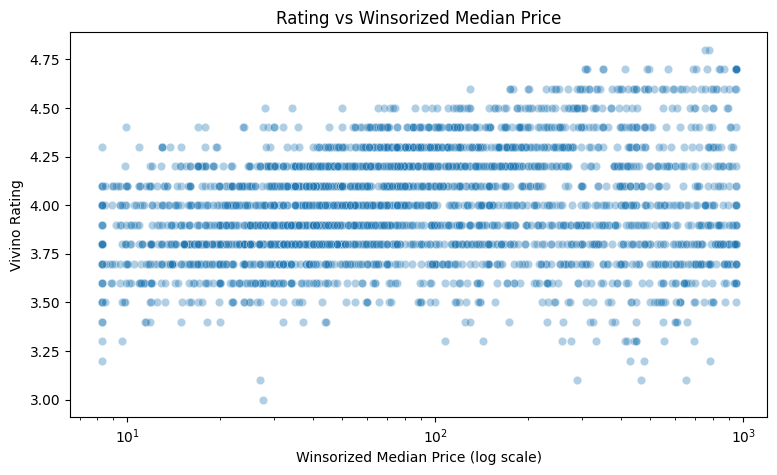

,price_band,wine_count,avg_rating,median_rating_count,median_price
0,Low,747,3.87,"1,184.00",20.38
1,Medium,746,4.00,792.50,50.60
2,High,746,4.09,692.00,119.90
3,Premium,747,4.02,"1,064.00",450.00


In [39]:
# Visualize rating vs winsorized median price
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=italian_wines,
    x="median_price_winsorized",
    y="rating",
    alpha=0.35
)

plt.xscale("log")
plt.title("Rating vs Winsorized Median Price")
plt.xlabel("Winsorized Median Price (log scale)")
plt.ylabel("Vivino Rating")
plt.show()

# Price bands for cross-dimensional interpretation
italian_wines["price_band"] = pd.qcut(
    italian_wines["median_price_winsorized"],
    q=4,
    labels=["Low", "Medium", "High", "Premium"]
)

price_band_summary = (
    italian_wines
    .groupby("price_band", observed=True)
    .agg(
        wine_count=("name", "count"),
        avg_rating=("rating", "mean"),
        median_rating_count=("rating_count", "median"),
        median_price=("median_price", "median")
    )
    .reset_index()
    .round(2)
)

display(price_band_summary)

### Relationship Analysis Interpretation

This deeper analysis helps test whether higher prices are clearly associated with higher ratings or stronger consumer visibility. If the correlation between rating and price is weak, then expensive wines should not automatically be treated as better opportunities.

The price-band summary also supports commercial interpretation. It helps distinguish premium positioning from value-for-money potential and supports the later recommendation that Slurpini should use a balanced portfolio strategy rather than selecting only high-price or high-rating regions.

### 8.3 Regional Analysis

Regional analysis is important because Slurpini can use it to identify Italian wine areas that show strong consumer appeal in the Dutch market.

This section compares Italian regions using four indicators:

- Number of wines in the dataset
- Average consumer rating
- Median rating count as a popularity indicator
- Median price as a market-positioning indicator

To avoid misleading conclusions from very small regions, the analysis separates broad regional representation from performance-based ranking.

In [40]:
# ============================================================
# 8.1 Regional Analysis
# ============================================================

region_summary = (
    italian_wines
    .groupby("region_clean")
    .agg(
        wine_count=("name", "count"),
        avg_rating=("rating", "mean"),
        median_rating=("rating", "median"),
        avg_rating_count=("rating_count", "mean"),
        median_rating_count=("rating_count", "median"),
        avg_median_price=("median_price", "mean"),
        median_price=("median_price", "median")
    )
    .reset_index()
)

# Round selected columns for cleaner display
region_summary = region_summary.round({
    "avg_rating": 2,
    "median_rating": 2,
    "avg_rating_count": 2,
    "median_rating_count": 2,
    "avg_median_price": 2,
    "median_price": 2
})

region_summary.sort_values("wine_count", ascending=False).head(20)

,region_clean,wine_count,avg_rating,median_rating,avg_rating_count,median_rating_count,avg_median_price,median_price
148,Toscane,332,4.05,4.00,"2,225.06",965.00,237.74,99.32
15,Barolo,200,4.18,4.20,835.27,476.50,212.00,142.36
25,Brunello di Montalcino,194,4.26,4.30,"1,589.80","1,020.00",172.53,99.72
35,Chianti Classico,185,3.94,3.90,"1,661.18","1,201.00",172.06,54.57
144,Terre Siciliane,98,3.87,3.90,"1,290.31",976.00,236.25,89.45
114,Prosecco,81,3.67,3.70,"3,301.72","2,015.00",130.89,23.99
163,Veneto,67,3.93,3.90,"1,404.42","1,022.00",162.84,47.95
117,Puglia,67,3.92,4.00,"1,492.87",998.00,165.62,69.00
98,Montepulciano d'Abruzzo,60,3.83,3.80,"1,920.10","1,016.00",204.25,74.39
5,Amarone della Valpolicella Classico,59,4.34,4.30,"3,157.95","1,413.00",227.33,117.95


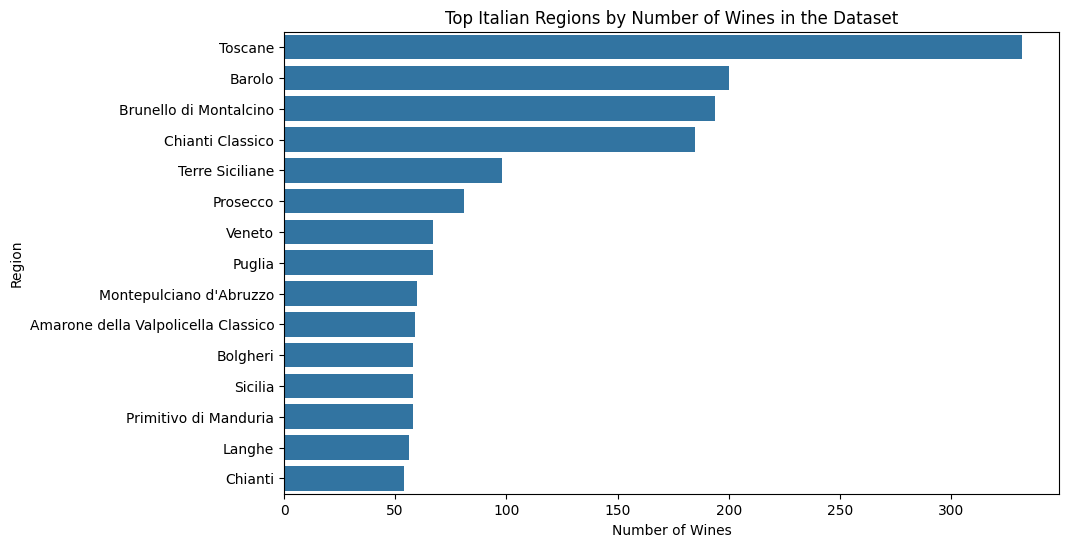

In [41]:
# Top Italian regions by number of wines
top_regions_by_count = region_summary.sort_values("wine_count", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_regions_by_count,
    x="wine_count",
    y="region_clean"
)

plt.title("Top Italian Regions by Number of Wines in the Dataset")
plt.xlabel("Number of Wines")
plt.ylabel("Region")
plt.show()

In [42]:
# Rank regions by average rating, using a minimum number of wines for reliability
min_region_wines = 20

top_regions_by_rating = (
    region_summary[region_summary["wine_count"] >= min_region_wines]
    .sort_values("avg_rating", ascending=False)
    .head(15)
)

top_regions_by_rating

,region_clean,wine_count,avg_rating,median_rating,avg_rating_count,median_rating_count,avg_median_price,median_price
21,Bolgheri Sassicaia,22,4.62,4.60,"4,140.91","3,527.00",605.87,554.50
22,Bolgheri Superiore,39,4.46,4.50,"1,637.62","1,474.00",273.65,245.00
5,Amarone della Valpolicella Classico,59,4.34,4.30,"3,157.95","1,413.00",227.33,117.95
25,Brunello di Montalcino,194,4.26,4.30,"1,589.80","1,020.00",172.53,99.72
4,Amarone della Valpolicella,33,4.24,4.20,"1,067.52",789.00,186.69,102.49
113,Primitivo di Manduria,58,4.21,4.20,"2,107.60","1,166.00",163.41,93.49
15,Barolo,200,4.18,4.20,835.27,476.50,212.00,142.36
10,Barbaresco,54,4.14,4.20,864.70,296.50,191.74,143.88
20,Bolgheri,58,4.08,4.10,"2,093.52","1,482.50",192.42,70.00
148,Toscane,332,4.05,4.00,"2,225.06",965.00,237.74,99.32


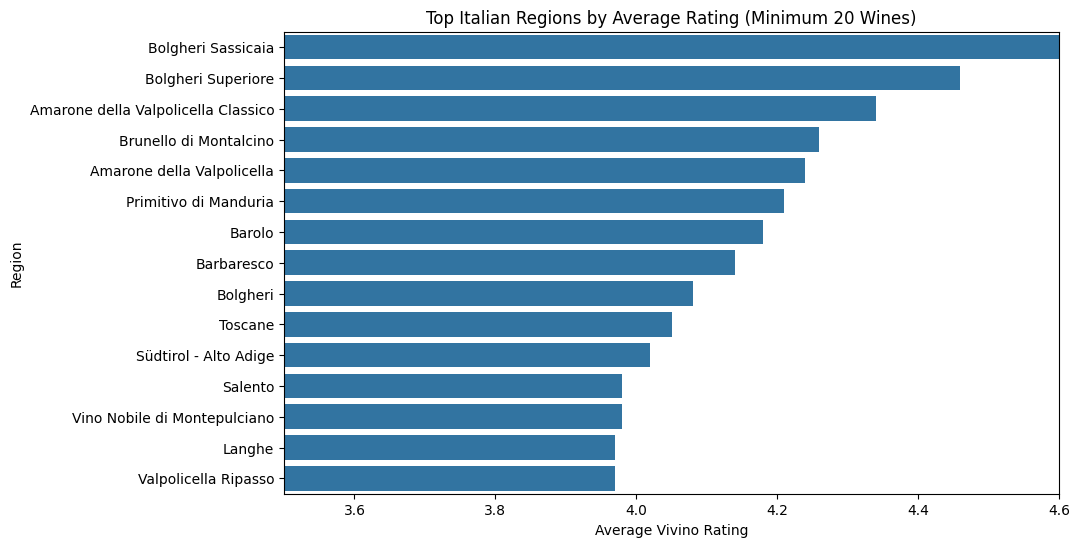

In [43]:
# Visualize top regions by average rating
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_regions_by_rating,
    x="avg_rating",
    y="region_clean"
)

plt.title(f"Top Italian Regions by Average Rating (Minimum {min_region_wines} Wines)")
plt.xlabel("Average Vivino Rating")
plt.ylabel("Region")
plt.xlim(3.5, 4.6)
plt.show()

In [44]:
# Rank regions by median rating count, using a minimum number of wines for reliability
top_regions_by_popularity = (
    region_summary[region_summary["wine_count"] >= min_region_wines]
    .sort_values("median_rating_count", ascending=False)
    .head(15)
)

top_regions_by_popularity

,region_clean,wine_count,avg_rating,median_rating,avg_rating_count,median_rating_count,avg_median_price,median_price
21,Bolgheri Sassicaia,22,4.62,4.60,"4,140.91","3,527.00",605.87,554.50
66,Franciacorta,36,3.86,3.80,"4,136.92","2,391.00",66.00,34.48
114,Prosecco,81,3.67,3.70,"3,301.72","2,015.00",130.89,23.99
20,Bolgheri,58,4.08,4.10,"2,093.52","1,482.50",192.42,70.00
22,Bolgheri Superiore,39,4.46,4.50,"1,637.62","1,474.00",273.65,245.00
115,Prosecco di Treviso,31,3.70,3.70,"3,094.03","1,463.00",147.16,39.00
5,Amarone della Valpolicella Classico,59,4.34,4.30,"3,157.95","1,413.00",227.33,117.95
175,Vino Nobile di Montepulciano,28,3.98,4.00,"1,609.61","1,360.50",240.75,84.69
12,Barbera d'Asti,31,3.94,3.90,"1,367.90","1,278.00",179.93,66.00
157,Valpolicella,23,3.81,3.70,"1,637.22","1,225.00",125.27,35.85


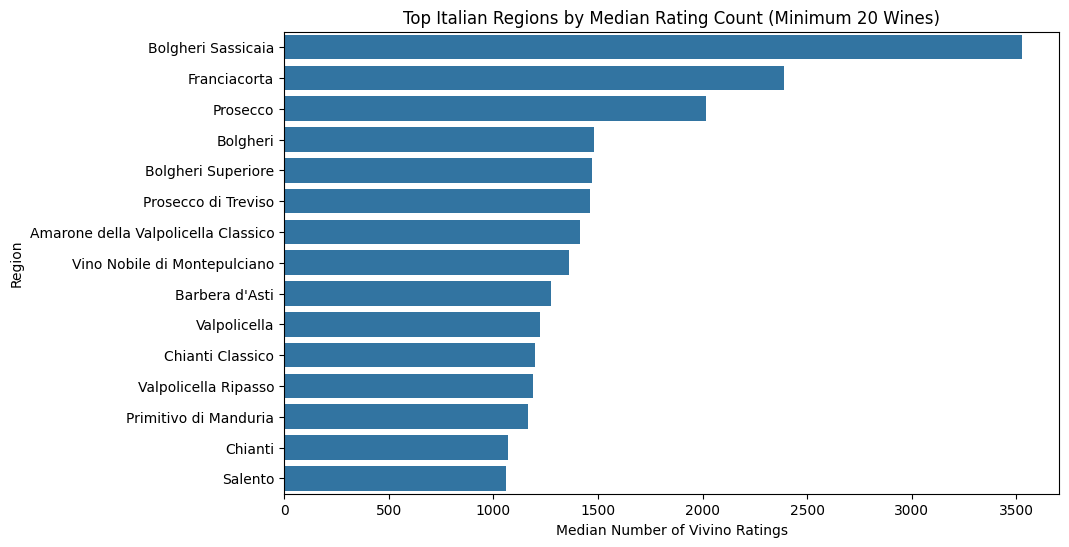

In [45]:
# Visualize top regions by median rating count
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_regions_by_popularity,
    x="median_rating_count",
    y="region_clean"
)

plt.title(f"Top Italian Regions by Median Rating Count (Minimum {min_region_wines} Wines)")
plt.xlabel("Median Number of Vivino Ratings")
plt.ylabel("Region")
plt.show()

### Regional Analysis Observations

The regional analysis helps distinguish between regions that are strongly represented in the dataset and regions that perform well on consumer preference indicators.

A region with many wines in the dataset may indicate broad market availability or stronger representation on Vivino. However, high representation alone does not mean the region is the best recommendation for Slurpini. For partnership decisions, `rating`, `quality` and `popularity` should be considered together.

To improve reliability, performance rankings use a minimum sample-size threshold. This prevents regions with only a few wines from appearing as strong recommendations based on limited evidence.

## 9. Value-for-Money Analysis

Value-for-money analysis helps identify wines and regions that offer strong consumer satisfaction at a relatively reasonable price.

For Slurpini, this is commercially important because potential partnerships should not only focus on highly rated premium wines. A wine or region may also be attractive if it combines good ratings, sufficient market validation, and accessible pricing.

In this section, value for money is evaluated using `rating`, `rating count`, and `median price`. Wines with very low rating counts are filtered out to avoid recommending products with limited consumer evidence.

In [46]:
# ============================================================
# 9. Value-for-Money Analysis
# Create value metrics
# ============================================================

# Use the winsorized price column for value metrics to reduce sensitivity to extreme prices.
# The original median_price is still kept for reporting and business interpretation.
value_df = italian_wines.copy()

min_rating_count = 100
value_df = value_df[value_df["rating_count"] >= min_rating_count].copy()
value_df = value_df[value_df["median_price_winsorized"] > 0].copy()

value_df["price_for_value"] = value_df["median_price_winsorized"]

# Simple value metric: rating relative to price
value_df["rating_per_euro"] = value_df["rating"] / value_df["price_for_value"]

# Popularity-adjusted value metric
# log1p reduces the impact of very large rating counts
value_df["weighted_value_score"] = (
    value_df["rating"] * np.log1p(value_df["rating_count"])
) / value_df["price_for_value"]

print("Value-for-money dataset created successfully.")
print(f"Rows before rating-count filter: {italian_wines.shape[0]:,}")
print(f"Rows after rating-count filter: {value_df.shape[0]:,}")
print(f"Minimum rating count used: {min_rating_count}")
print("Price column used for value metrics: median_price_winsorized")

value_df[[
    "name",
    "region_clean",
    "rating",
    "rating_count",
    "median_price",
    "price_for_value",
    "rating_per_euro",
    "weighted_value_score"
]].head()

Value-for-money dataset created successfully.
Rows before rating-count filter: 2,986
Rows after rating-count filter: 2,982
Minimum rating count used: 100
Price column used for value metrics: median_price_winsorized


,name,region_clean,rating,rating_count,median_price,price_for_value,rating_per_euro,weighted_value_score
0,47 Anno Domini Le Argille Cabernet di Cabernet...,Veneto,4.30,570,28.99,28.99,0.15,0.94
1,ARPEPE Il Pettirosso 2017,Valtellina Superiore,4.00,492,93.38,93.38,0.04,0.27
2,ARPEPE Inferno Sesto Canto Riserva Valtellina ...,Valtellina Superiore,4.20,126,180.00,180.00,0.02,0.11
3,ARPEPE Rosso di Valtellina 2016,Valtellina,3.80,1429,37.00,37.00,0.10,0.75
4,ARPEPE Rosso di Valtellina 2020,Valtellina,3.80,536,66.00,66.00,0.06,0.36


In [47]:
# Top wines by simple rating-per-euro metric
top_wines_simple_value = (
    value_df
    .sort_values("rating_per_euro", ascending=False)
    .head(20)
)

top_wines_simple_value[
    ["name", "region_clean", "rating", "rating_count", "median_price", "price_for_value", "rating_per_euro"]
]

,name,region_clean,rating,rating_count,median_price,price_for_value,rating_per_euro
1559,Luna Argenta Appassimento Rosso 2020,Terre Siciliane,4.30,1367,7.50,8.26,0.52
526,Ca' del Doge Fioroso Cuvée Frizzante Bianco N.V.,Veneto,4.10,1064,6.90,8.26,0.50
785,Cesari Pinot Grigio delle Venezie 2021,delle Venezie,4.10,567,7.90,8.26,0.50
799,Cielo e Terra Appassionante 2020,Veneto,4.10,358,6.99,8.26,0.50
808,Cinzano Vermouth Bianco N.V.,Piemonte,4.00,560,7.50,8.26,0.48
235,Aristocratico Appassimento 2020,Salento,4.00,1330,7.45,8.26,0.48
1812,Montedidio Stuni 2020,Puglia,4.00,1198,7.95,8.26,0.48
1931,Passaia Gran Passaia Toscana 2019,Toscane,4.00,1433,6.90,8.26,0.48
815,Cleto Chiarli Centenario Lambrusco Grasparossa...,Lambrusco Grasparossa di Castelvetro,4.00,2831,8.28,8.28,0.48
1561,Luna Argenta Appassite Negroamaro - Primitivo ...,Puglia,4.10,1699,8.49,8.49,0.48


In [48]:
# Top wines by popularity-adjusted value score
top_wines_weighted_value = (
    value_df
    .sort_values("weighted_value_score", ascending=False)
    .head(20)
)

top_wines_weighted_value[
    ["name", "region_clean", "rating", "rating_count", "median_price", "price_for_value", "weighted_value_score"]
]

,name,region_clean,rating,rating_count,median_price,price_for_value,weighted_value_score
255,Astrale Rosso N.V.,Vino dItalia,4.10,32292,9.99,9.99,4.26
1018,Doppio Passo Primitivo 2020,Puglia,4.10,10344,8.95,8.95,4.23
251,Astrale Bianco N.V.,Vino dItalia,3.90,7687,7.00,8.26,4.23
802,Cielo e Terra Prosecco Frizzante N.V.,Prosecco,3.80,5305,6.50,8.26,3.95
749,Cavicchioli Lambrusco dell'Emilia Dolce Rosso ...,Emilia,3.80,4614,8.13,8.26,3.88
1607,Martini Asti N.V.,Asti,3.80,23891,9.92,9.92,3.86
815,Cleto Chiarli Centenario Lambrusco Grasparossa...,Lambrusco Grasparossa di Castelvetro,4.00,2831,8.28,8.28,3.84
1163,Fontanafredda Asti Dolce N.V.,Asti,3.70,5178,8.09,8.26,3.83
1559,Luna Argenta Appassimento Rosso 2020,Terre Siciliane,4.30,1367,7.50,8.26,3.76
1019,Doppio Passo Primitivo 2021,Puglia,4.10,5044,9.30,9.30,3.76


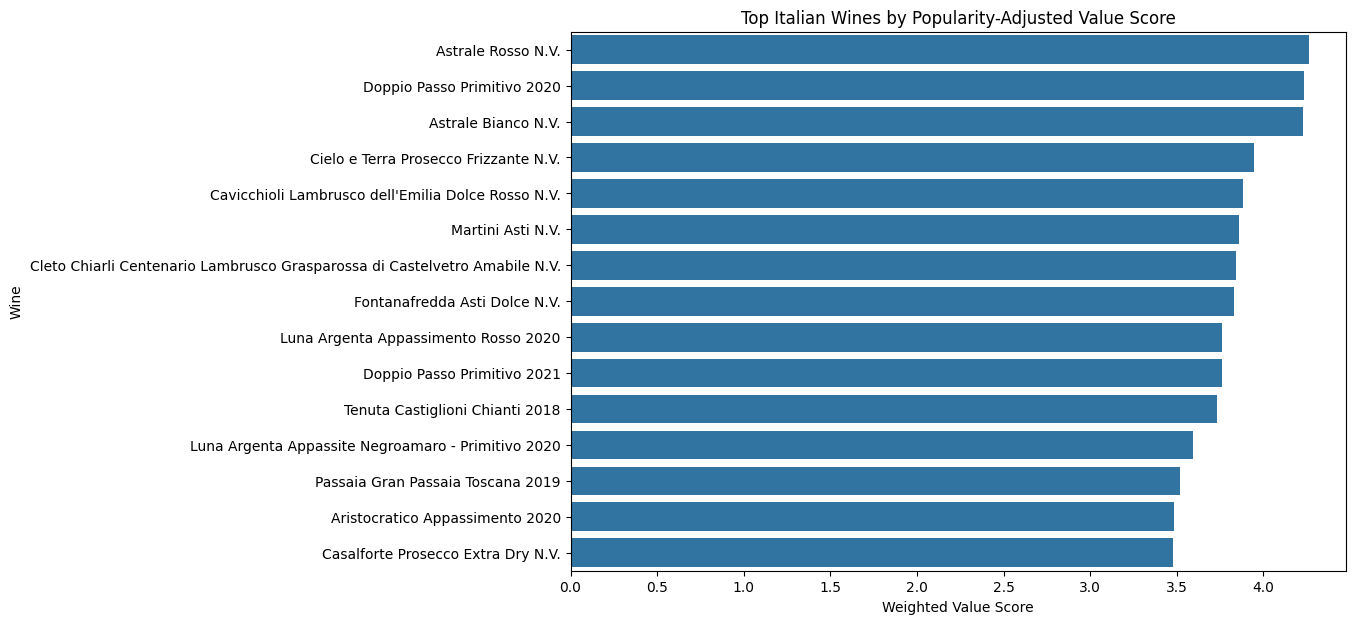

In [49]:
# Visualize top wines by weighted value score
top_15_weighted_value = top_wines_weighted_value.head(15).copy()

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_15_weighted_value,
    x="weighted_value_score",
    y="name"
)

plt.title("Top Italian Wines by Popularity-Adjusted Value Score")
plt.xlabel("Weighted Value Score")
plt.ylabel("Wine")
plt.show()

In [50]:
# Region-level value-for-money summary
region_value_summary = (
    value_df
    .groupby("region_clean")
    .agg(
        wine_count=("name", "count"),
        avg_rating=("rating", "mean"),
        median_rating_count=("rating_count", "median"),
        median_price=("median_price", "median"),
        median_price_for_value=("price_for_value", "median"),
        avg_weighted_value_score=("weighted_value_score", "mean")
    )
    .reset_index()
)

region_value_summary = region_value_summary.round({
    "avg_rating": 2,
    "median_rating_count": 2,
    "median_price": 2,
    "median_price_for_value": 2,
    "avg_weighted_value_score": 4
})

min_region_wines_value = 10

top_regions_by_value = (
    region_value_summary[region_value_summary["wine_count"] >= min_region_wines_value]
    .sort_values("avg_weighted_value_score", ascending=False)
    .head(15)
)

top_regions_by_value

,region_clean,wine_count,avg_rating,median_rating_count,median_price,median_price_for_value,avg_weighted_value_score
176,Vino dItalia,18,3.93,"1,781.50",39.01,39.01,1.47
48,Conegliano-Valdobbiadene Prosecco Superiore,17,3.79,"2,937.00",29.20,29.20,1.33
114,Prosecco,81,3.67,"2,015.00",23.99,23.99,1.32
115,Prosecco di Treviso,31,3.70,"1,463.00",39.00,39.00,1.18
117,Puglia,67,3.92,998.00,69.00,69.00,1.13
59,Emilia,13,3.88,"1,064.00",30.92,30.92,1.12
131,Salento,52,3.98,"1,079.00",41.96,41.96,1.06
8,Asti,10,3.88,"2,868.00",201.30,201.30,1.03
100,Moscato d'Asti,19,4.14,864.00,29.99,29.99,1.00
163,Veneto,67,3.93,"1,022.00",47.95,47.95,0.98


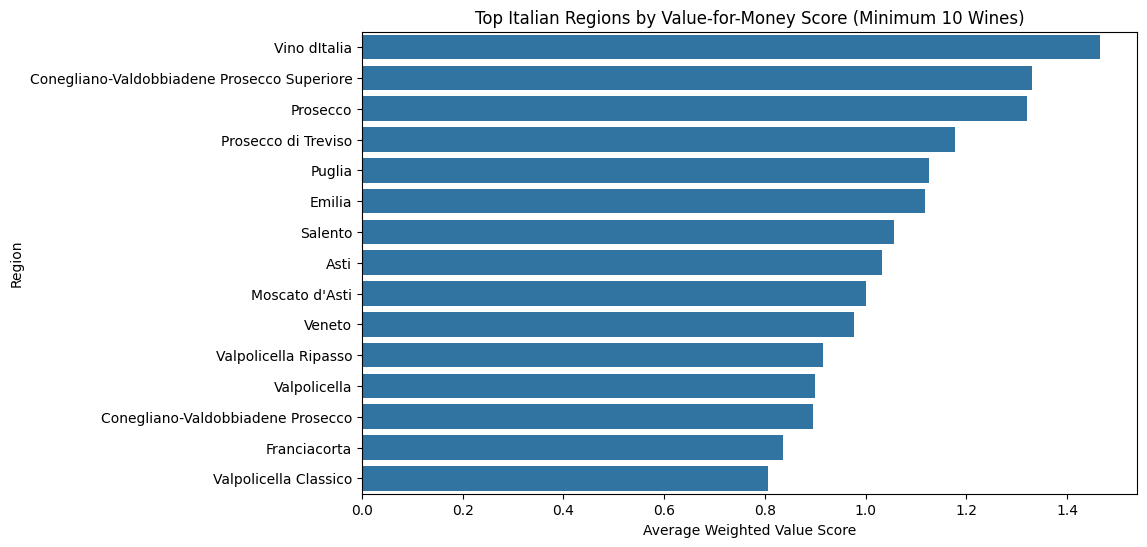

In [51]:
# Visualize top regions by average weighted value score
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_regions_by_value,
    x="avg_weighted_value_score",
    y="region_clean"
)

plt.title(f"Top Italian Regions by Value-for-Money Score (Minimum {min_region_wines_value} Wines)")
plt.xlabel("Average Weighted Value Score")
plt.ylabel("Region")
plt.show()

### 9.1 Value Metric Sensitivity Analysis

The value-for-money metric uses two design choices: a minimum rating-count threshold and a transformation of rating count.  
To check whether the results are robust, this section reruns the value ranking under different assumptions.

This helps separate regions that are consistently strong from regions that only appear under one specific metric setting.

In [52]:
# ============================================================
# 9.1 Value Metric Sensitivity Analysis
# ============================================================

def compute_region_value_sensitivity(
    df: pd.DataFrame,
    min_rating_count: int,
    transform_name: str,
    min_region_wines: int = 10,
    top_n: int = 10
) -> pd.DataFrame:
    """
    Compute top value-for-money regions under different rating-count thresholds
    and rating-count transformations.
    """
    temp = df[df["rating_count"] >= min_rating_count].copy()
    temp = temp[temp["median_price_winsorized"] > 0].copy()

    if transform_name == "log1p":
        rating_count_component = np.log1p(temp["rating_count"])
    elif transform_name == "sqrt":
        rating_count_component = np.sqrt(temp["rating_count"])
    else:
        raise ValueError("transform_name must be either 'log1p' or 'sqrt'")

    temp["sensitivity_value_score"] = (
        temp["rating"] * rating_count_component
    ) / temp["median_price_winsorized"]

    ranking = (
        temp
        .groupby("region_clean")
        .agg(
            wine_count=("name", "count"),
            avg_rating=("rating", "mean"),
            median_rating_count=("rating_count", "median"),
            median_price=("median_price", "median"),
            avg_sensitivity_value_score=("sensitivity_value_score", "mean")
        )
        .reset_index()
    )

    ranking = ranking[ranking["wine_count"] >= min_region_wines].copy()
    ranking = ranking.sort_values("avg_sensitivity_value_score", ascending=False)

    return ranking.head(top_n).reset_index(drop=True)


baseline_top10 = compute_region_value_sensitivity(
    italian_wines,
    min_rating_count=100,
    transform_name="log1p"
)

baseline_regions = set(baseline_top10["region_clean"])

sensitivity_records = []
region_frequency = {}

for threshold in [50, 100, 250]:
    for transform in ["log1p", "sqrt"]:
        ranking = compute_region_value_sensitivity(
            italian_wines,
            min_rating_count=threshold,
            transform_name=transform
        )

        regions = list(ranking["region_clean"])
        overlap = len(set(regions).intersection(baseline_regions))

        sensitivity_records.append({
            "min_rating_count": threshold,
            "transform": transform,
            "top10_overlap_with_baseline": overlap,
            "top_regions": ", ".join(regions[:5])
        })

        for region in regions:
            region_frequency[region] = region_frequency.get(region, 0) + 1

value_metric_sensitivity = pd.DataFrame(sensitivity_records)

robust_value_regions = (
    pd.DataFrame({
        "region_clean": list(region_frequency.keys()),
        "top10_frequency_across_scenarios": list(region_frequency.values())
    })
    .sort_values("top10_frequency_across_scenarios", ascending=False)
    .reset_index(drop=True)
)

display(value_metric_sensitivity)
display(robust_value_regions.head(15))

,min_rating_count,transform,top10_overlap_with_baseline,top_regions
0,50,log1p,10,"Vino dItalia, Conegliano-Valdobbiadene Prosecc..."
1,50,sqrt,8,"Vino dItalia, Conegliano-Valdobbiadene Prosecc..."
2,100,log1p,10,"Vino dItalia, Conegliano-Valdobbiadene Prosecc..."
3,100,sqrt,8,"Vino dItalia, Conegliano-Valdobbiadene Prosecc..."
4,250,log1p,10,"Vino dItalia, Prosecco, Conegliano-Valdobbiade..."
5,250,sqrt,9,"Vino dItalia, Conegliano-Valdobbiadene Prosecc..."


,region_clean,top10_frequency_across_scenarios
0,Vino dItalia,6
1,Conegliano-Valdobbiadene Prosecco Superiore,6
2,Prosecco,6
3,Prosecco di Treviso,6
4,Puglia,6
5,Emilia,6
6,Asti,6
7,Moscato d'Asti,6
8,Salento,4
9,Veneto,3


### Value Metric Sensitivity Interpretation

The sensitivity analysis tests whether the value-for-money ranking depends too strongly on one threshold or transformation. Regions that appear repeatedly across scenarios can be treated as more robust value opportunities.

Regions that only appear in one scenario should be interpreted as more borderline. They may still be interesting, but they require additional validation before being placed in a final shortlist.

### Value-for-Money Analysis Observations

The `value-for-money analysis` combines `consumer rating`, `rating count`, and `price` to identify wines and regions that appear commercially attractive.

A simple `rating-per-euro metric` is useful for identifying low-priced wines with good ratings, but it can over-prioritize very cheap wines. For this reason, a `popularity-adjusted value score` was also created. This score rewards wines with strong ratings and stronger consumer validation while still accounting for price.

For Slurpini, the `value-for-money results` can support a different type of recommendation than the `premium-region analysis`. Premium regions may be attractive for `brand positioning`, while value-oriented wines and regions may be more suitable for accessible consumer offerings or hospitality clients looking for strong quality at manageable prices.

## 10. Producer and Region Scoring Model

The business objective is to help Slurpini pre-select promising Italian wine opportunities using objective indicators from Vivino data.

Because the dataset does not contain a separate structured `producer column`, this project first builds a `region-level scoring model`. A region-level model is appropriate because wine regions are commercially meaningful in the wine industry and can help Slurpini prioritize where to focus supplier research and partnership exploration.

The scoring model combines five dimensions:

- **Quality:** average Vivino rating
- **Popularity:** median number of consumer ratings
- **Value for money:** average popularity-adjusted value score
- **Reliability:** number of wines available in the dataset
- **Price accessibility:** lower median prices receive a higher accessibility score

The model is designed to support business decision-making, not to replace human judgment. Final recommendations should still consider sustainability fit, producer availability, logistics, brand alignment, and direct supplier conversations.

In [53]:
# ============================================================
# 10. Producer and Region Scoring Model
# Prepare region-level scoring dataset
# ============================================================

# Start from the region-level value summary
region_model = region_value_summary.copy()

# Use only regions with enough wines for more reliable comparison
min_wines_for_model = 10
region_model = region_model[region_model["wine_count"] >= min_wines_for_model].copy()

print("Region scoring dataset prepared.")
print(f"Regions before filtering: {region_value_summary.shape[0]:,}")
print(f"Regions after filtering: {region_model.shape[0]:,}")
print(f"Minimum wines per region: {min_wines_for_model}")

region_model.head()

Region scoring dataset prepared.
Regions before filtering: 179
Regions after filtering: 59
Minimum wines per region: 10


,region_clean,wine_count,avg_rating,median_rating_count,median_price,median_price_for_value,avg_weighted_value_score
4,Amarone della Valpolicella,33,4.24,789.00,102.49,102.49,0.44
5,Amarone della Valpolicella Classico,59,4.34,"1,413.00",117.95,117.95,0.28
8,Asti,10,3.88,"2,868.00",201.30,201.30,1.03
10,Barbaresco,54,4.14,296.50,143.88,143.88,0.22
11,Barbera d'Alba,31,3.92,734.00,52.00,52.00,0.58


In [54]:
# ============================================================
# Normalize model inputs
# ============================================================

# Higher is better
region_model["quality_score"] = min_max_scale(region_model["avg_rating"])
region_model["popularity_score"] = min_max_scale(np.log1p(region_model["median_rating_count"]))
region_model["value_score"] = min_max_scale(region_model["avg_weighted_value_score"])
region_model["reliability_score"] = min_max_scale(np.log1p(region_model["wine_count"]))

# Lower price is better for accessibility.
# The winsorized median price is used when available to reduce outlier influence.
price_column_for_accessibility = (
    "median_price_for_value"
    if "median_price_for_value" in region_model.columns
    else "median_price"
)

region_model["price_accessibility_score"] = 1 - min_max_scale(
    np.log1p(region_model[price_column_for_accessibility])
)

region_model[
    [
        "region_clean",
        "wine_count",
        "avg_rating",
        "median_rating_count",
        "median_price",
        "avg_weighted_value_score",
        "quality_score",
        "popularity_score",
        "value_score",
        "reliability_score",
        "price_accessibility_score"
    ]
].head()

,region_clean,wine_count,avg_rating,median_rating_count,median_price,avg_weighted_value_score,quality_score,popularity_score,value_score,reliability_score,price_accessibility_score
4,Amarone della Valpolicella,33,4.24,789.00,102.49,0.44,0.63,0.39,0.26,0.33,0.54
5,Amarone della Valpolicella Classico,59,4.34,"1,413.00",117.95,0.28,0.73,0.63,0.15,0.50,0.50
8,Asti,10,3.88,"2,868.00",201.30,1.03,0.28,0.92,0.69,0.00,0.33
10,Barbaresco,54,4.14,296.50,143.88,0.22,0.53,0.00,0.11,0.47,0.43
11,Barbera d'Alba,31,3.92,734.00,52.00,0.58,0.32,0.37,0.37,0.31,0.76


### Scoring Logic

The model uses normalized scores between 0 and 1 so that indicators with different units can be compared and combined.

The final opportunity score uses the following weighting:

- Quality score: 30%
- Popularity score: 25%
- Value-for-money score: 20%
- Reliability score: 15%
- Price accessibility score: 10%

Quality and popularity receive the highest weights because Slurpini is positioned as an importer of high-quality wines and needs evidence of consumer preference in the Dutch market. Value for money is also important, but it should not dominate the recommendation because Slurpini is not positioned as a low-cost wine importer.

In [55]:
# ============================================================
# Calculate final region opportunity score
# ============================================================

weights = {
    "quality_score": 0.30,
    "popularity_score": 0.25,
    "value_score": 0.20,
    "reliability_score": 0.15,
    "price_accessibility_score": 0.10
}

region_model["region_opportunity_score"] = (
    region_model["quality_score"] * weights["quality_score"] +
    region_model["popularity_score"] * weights["popularity_score"] +
    region_model["value_score"] * weights["value_score"] +
    region_model["reliability_score"] * weights["reliability_score"] +
    region_model["price_accessibility_score"] * weights["price_accessibility_score"]
)

region_model["region_opportunity_score"] = region_model["region_opportunity_score"].round(4)

top_region_opportunities = (
    region_model
    .sort_values("region_opportunity_score", ascending=False)
    .reset_index(drop=True)
)

top_region_opportunities.head(20)[
    [
        "region_clean",
        "wine_count",
        "avg_rating",
        "median_rating_count",
        "median_price",
        "avg_weighted_value_score",
        "region_opportunity_score"
    ]
]

,region_clean,wine_count,avg_rating,median_rating_count,median_price,avg_weighted_value_score,region_opportunity_score
0,Vino dItalia,18,3.93,"1,781.50",39.01,1.47,0.59
1,Conegliano-Valdobbiadene Prosecco Superiore,17,3.79,"2,937.00",29.20,1.33,0.59
2,Prosecco,81,3.67,"2,015.00",23.99,1.32,0.58
3,Bolgheri Sassicaia,22,4.62,"3,527.00",554.50,0.07,0.58
4,Primitivo di Manduria,58,4.21,"1,166.00",93.49,0.72,0.54
5,Franciacorta,36,3.86,"2,391.00",34.48,0.84,0.54
6,Brunello di Montalcino,194,4.26,"1,020.00",99.72,0.33,0.54
7,Salento,52,3.98,"1,079.00",41.96,1.06,0.54
8,Amarone della Valpolicella Classico,59,4.34,"1,413.00",117.95,0.28,0.53
9,Toscane,331,4.05,966.00,99.65,0.52,0.52


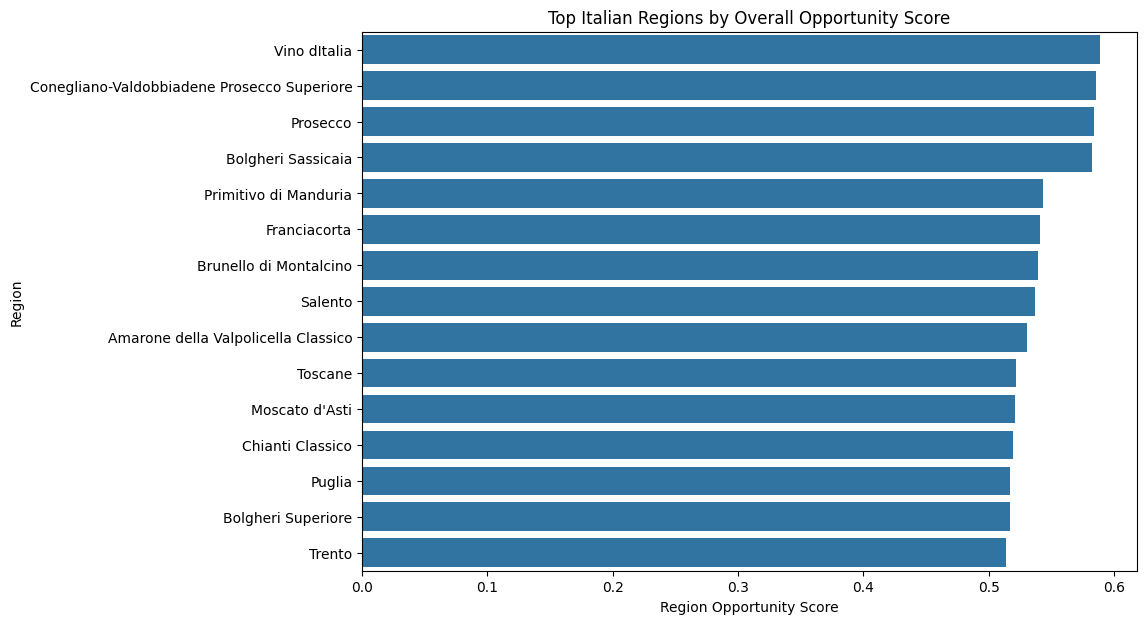

In [56]:
# Visualize top regions by opportunity score
top_15_region_opportunities = top_region_opportunities.head(15).copy()

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_15_region_opportunities,
    x="region_opportunity_score",
    y="region_clean"
)

plt.title("Top Italian Regions by Overall Opportunity Score")
plt.xlabel("Region Opportunity Score")
plt.ylabel("Region")
plt.show()

### 10.1 Region Scoring Robustness Check

The region opportunity score uses business weights. Because weight choices can influence rankings, this section tests whether top regions remain stable under alternative strategic priorities.

The scenarios below compare the baseline model with quality-focused, value-focused, and popularity-focused alternatives.

In [57]:
# ============================================================
# 10.1 Region Scoring Robustness Check
# ============================================================

weight_scenarios = {
    "baseline": {
        "quality_score": 0.30,
        "popularity_score": 0.25,
        "value_score": 0.20,
        "reliability_score": 0.15,
        "price_accessibility_score": 0.10
    },
    "quality_focused": {
        "quality_score": 0.45,
        "popularity_score": 0.20,
        "value_score": 0.15,
        "reliability_score": 0.10,
        "price_accessibility_score": 0.10
    },
    "value_focused": {
        "quality_score": 0.20,
        "popularity_score": 0.20,
        "value_score": 0.35,
        "reliability_score": 0.10,
        "price_accessibility_score": 0.15
    },
    "popularity_focused": {
        "quality_score": 0.20,
        "popularity_score": 0.40,
        "value_score": 0.15,
        "reliability_score": 0.15,
        "price_accessibility_score": 0.10
    }
}

baseline_regions_top10 = set(top_region_opportunities.head(10)["region_clean"])

scoring_sensitivity_records = []
scenario_top_regions = {}

for scenario_name, scenario_weights in weight_scenarios.items():
    temp = region_model.copy()

    temp["scenario_score"] = sum(
        temp[score_column] * weight
        for score_column, weight in scenario_weights.items()
    )

    temp = temp.sort_values("scenario_score", ascending=False).reset_index(drop=True)
    top10_regions = list(temp.head(10)["region_clean"])

    scenario_top_regions[scenario_name] = top10_regions

    scoring_sensitivity_records.append({
        "scenario": scenario_name,
        "top10_overlap_with_baseline": len(set(top10_regions).intersection(baseline_regions_top10)),
        "top_5_regions": ", ".join(top10_regions[:5])
    })

scoring_sensitivity_summary = pd.DataFrame(scoring_sensitivity_records)

display(scoring_sensitivity_summary)

,scenario,top10_overlap_with_baseline,top_5_regions
0,baseline,10,"Vino dItalia, Conegliano-Valdobbiadene Prosecc..."
1,quality_focused,6,"Bolgheri Sassicaia, Bolgheri Superiore, Amaron..."
2,value_focused,5,"Vino dItalia, Conegliano-Valdobbiadene Prosecc..."
3,popularity_focused,5,"Conegliano-Valdobbiadene Prosecco Superiore, P..."


### Region Scoring Robustness Interpretation

This robustness check shows whether the region ranking is stable when Slurpini changes strategic priorities. Regions that stay near the top across several scenarios are stronger candidates for further investigation.

If a region appears only in one scenario, it may still be useful, but the recommendation depends more heavily on that specific business strategy.

In [58]:
# ============================================================
# Strategic region classification
# ============================================================

# Strategic categories are assigned using a reusable helper function from src/features.py.
# The region_model dataframe is passed explicitly so the function does not depend on hidden global state.

region_model["strategic_category"] = region_model.apply(
    lambda row: classify_region(row, region_model),
    axis=1
)

strategic_region_summary = (
    region_model
    .sort_values("region_opportunity_score", ascending=False)
    [
        [
            "region_clean",
            "strategic_category",
            "wine_count",
            "avg_rating",
            "median_rating_count",
            "median_price",
            "avg_weighted_value_score",
            "region_opportunity_score"
        ]
    ]
    .head(25)
)

strategic_region_summary

,region_clean,strategic_category,wine_count,avg_rating,median_rating_count,median_price,avg_weighted_value_score,region_opportunity_score
176,Vino dItalia,Value-for-money opportunity,18,3.93,"1,781.50",39.01,1.47,0.59
48,Conegliano-Valdobbiadene Prosecco Superiore,Value-for-money opportunity,17,3.79,"2,937.00",29.20,1.33,0.59
114,Prosecco,Value-for-money opportunity,81,3.67,"2,015.00",23.99,1.32,0.58
21,Bolgheri Sassicaia,Premium quality opportunity,22,4.62,"3,527.00",554.50,0.07,0.58
113,Primitivo di Manduria,Secondary opportunity,58,4.21,"1,166.00",93.49,0.72,0.54
66,Franciacorta,Value-for-money opportunity,36,3.86,"2,391.00",34.48,0.84,0.54
25,Brunello di Montalcino,Secondary opportunity,194,4.26,"1,020.00",99.72,0.33,0.54
131,Salento,Value-for-money opportunity,52,3.98,"1,079.00",41.96,1.06,0.54
5,Amarone della Valpolicella Classico,Premium quality opportunity,59,4.34,"1,413.00",117.95,0.28,0.53
148,Toscane,Secondary opportunity,331,4.05,966.00,99.65,0.52,0.52


### 10.2 Producer-Candidate Shortlist Deliverable

Akos's feedback highlighted that the original project was mostly region-level, while the business case asks for producer pre-selection.  
The dataset does not contain a clean producer column, so this section creates a conservative `producer_candidate` using a heuristic extraction from the wine name.

This is not treated as a final producer-identification system. The goal is to create a practical shortlist for manual review and follow-up research.

In [59]:
# ============================================================
# 10.2 Producer-Candidate Shortlist Deliverable
# ============================================================

producer_df = value_df.copy()

# Extract a producer candidate from the wine name using a conservative heuristic.
producer_df["producer_candidate"] = producer_df["name"].apply(extract_producer_from_name)

# Remove empty or very short candidates
producer_df = producer_df[
    producer_df["producer_candidate"].notna() &
    (producer_df["producer_candidate"].str.len() >= 3)
].copy()

# Representative wine: choose the strongest value-scoring wine for each producer-region pair.
representative_wines = (
    producer_df
    .sort_values("weighted_value_score", ascending=False)
    .drop_duplicates(subset=["producer_candidate", "region_clean"])
    [["producer_candidate", "region_clean", "name"]]
    .rename(columns={"name": "representative_wine"})
)

producer_summary = (
    producer_df
    .groupby(["producer_candidate", "region_clean"])
    .agg(
        wine_count=("name", "count"),
        avg_rating=("rating", "mean"),
        median_rating_count=("rating_count", "median"),
        median_price=("median_price", "median"),
        avg_weighted_value_score=("weighted_value_score", "mean")
    )
    .reset_index()
)

producer_summary = producer_summary.merge(
    representative_wines,
    on=["producer_candidate", "region_clean"],
    how="left"
)

# Keep candidates with at least one wine and enough rating evidence.
# Because producer extraction is heuristic, the final top candidates should still be manually validated.
min_producer_wines = 1
producer_model = producer_summary[producer_summary["wine_count"] >= min_producer_wines].copy()

producer_model["producer_quality_score"] = min_max_scale(producer_model["avg_rating"])
producer_model["producer_popularity_score"] = min_max_scale(np.log1p(producer_model["median_rating_count"]))
producer_model["producer_value_score"] = min_max_scale(producer_model["avg_weighted_value_score"])
producer_model["producer_evidence_score"] = min_max_scale(np.log1p(producer_model["wine_count"]))
producer_model["producer_price_accessibility_score"] = 1 - min_max_scale(np.log1p(producer_model["median_price"]))

producer_weights = {
    "producer_quality_score": 0.30,
    "producer_popularity_score": 0.25,
    "producer_value_score": 0.25,
    "producer_evidence_score": 0.10,
    "producer_price_accessibility_score": 0.10
}

producer_model["producer_candidate_score"] = sum(
    producer_model[column] * weight
    for column, weight in producer_weights.items()
)

producer_model["producer_candidate_score"] = producer_model["producer_candidate_score"].round(4)

def assign_price_band(price: float) -> str:
    if price < 30:
        return "Accessible"
    elif price < 75:
        return "Mid-range"
    elif price < 150:
        return "Premium"
    else:
        return "Ultra-premium"


producer_model["price_band"] = producer_model["median_price"].apply(assign_price_band)

producer_top20_for_review = (
    producer_model
    .sort_values("producer_candidate_score", ascending=False)
    .reset_index(drop=True)
    .head(20)
)

def producer_shortlist_justification(row: pd.Series) -> str:
    return (
        f"Strong rating ({row['avg_rating']:.2f}), "
        f"consumer validation (median rating count {row['median_rating_count']:.0f}), "
        f"and {row['price_band'].lower()} price profile."
    )


producer_shortlist = producer_top20_for_review.head(5).copy()
producer_shortlist["shortlist_justification"] = producer_shortlist.apply(
    producer_shortlist_justification,
    axis=1
)

producer_shortlist = producer_shortlist[
    [
        "producer_candidate",
        "region_clean",
        "representative_wine",
        "wine_count",
        "avg_rating",
        "median_rating_count",
        "median_price",
        "price_band",
        "producer_candidate_score",
        "shortlist_justification"
    ]
].round({
    "avg_rating": 2,
    "median_rating_count": 0,
    "median_price": 2,
    "producer_candidate_score": 4
})

print("Top 20 producer candidates prepared for manual validation.")
display(producer_top20_for_review[
    [
        "producer_candidate",
        "region_clean",
        "representative_wine",
        "wine_count",
        "avg_rating",
        "median_rating_count",
        "median_price",
        "producer_candidate_score"
    ]
].head(20).round(3))

print("Final Top 5 producer-candidate shortlist:")
display(producer_shortlist)

Top 20 producer candidates prepared for manual validation.


,producer_candidate,region_clean,representative_wine,wine_count,avg_rating,median_rating_count,median_price,producer_candidate_score
0,Astrale Rosso N.V.,Vino dItalia,Astrale Rosso N.V.,1,4.10,"32,292.00",9.99,0.74
1,Doppio Passo Primitivo,Puglia,Doppio Passo Primitivo 2020,2,4.10,"7,694.00",9.12,0.69
2,Villa Degli Olmi Corte dei Rovi Prosecco N.V.,Prosecco,Villa Degli Olmi Corte dei Rovi Prosecco N.V.,1,4.30,"12,321.00",12.95,0.67
3,Astrale Bianco N.V.,Vino dItalia,Astrale Bianco N.V.,1,3.90,"7,687.00",7.00,0.66
4,Martini Asti N.V.,Asti,Martini Asti N.V.,1,3.80,"23,891.00",9.92,0.66
5,Luna Argenta Appassimento Rosso,Terre Siciliane,Luna Argenta Appassimento Rosso 2020,1,4.30,"1,367.00",7.50,0.63
6,Stella Rosa Moscato d'Asti N.V.,Moscato d'Asti,Stella Rosa Moscato d'Asti N.V.,1,4.30,"4,714.00",12.99,0.61
7,Cantine di Ora Amicone,Veneto,Cantine di Ora Amicone 2018,1,4.10,"5,512.00",10.95,0.61
8,Cleto Chiarli Centenario Lambrusco Grasparossa...,Lambrusco Grasparossa di Castelvetro,Cleto Chiarli Centenario Lambrusco Grasparossa...,1,4.00,"2,831.00",8.28,0.61
9,Cielo e Terra Prosecco Frizzante N.V.,Prosecco,Cielo e Terra Prosecco Frizzante N.V.,1,3.80,"5,305.00",6.50,0.61


Final Top 5 producer-candidate shortlist:


,producer_candidate,region_clean,representative_wine,wine_count,avg_rating,median_rating_count,median_price,price_band,producer_candidate_score,shortlist_justification
0,Astrale Rosso N.V.,Vino dItalia,Astrale Rosso N.V.,1,4.10,"32,292.00",9.99,Accessible,0.74,"Strong rating (4.10), consumer validation (med..."
1,Doppio Passo Primitivo,Puglia,Doppio Passo Primitivo 2020,2,4.10,"7,694.00",9.12,Accessible,0.69,"Strong rating (4.10), consumer validation (med..."
2,Villa Degli Olmi Corte dei Rovi Prosecco N.V.,Prosecco,Villa Degli Olmi Corte dei Rovi Prosecco N.V.,1,4.30,"12,321.00",12.95,Accessible,0.67,"Strong rating (4.30), consumer validation (med..."
3,Astrale Bianco N.V.,Vino dItalia,Astrale Bianco N.V.,1,3.90,"7,687.00",7.00,Accessible,0.66,"Strong rating (3.90), consumer validation (med..."
4,Martini Asti N.V.,Asti,Martini Asti N.V.,1,3.80,"23,891.00",9.92,Accessible,0.66,"Strong rating (3.80), consumer validation (med..."


### Producer Shortlist Interpretation

The producer shortlist is intentionally labelled as a `producer-candidate` shortlist because the producer name is extracted from the wine-name text using a heuristic. This makes the deliverable useful for business pre-selection, but it still requires manual validation.

For Slurpini, the shortlist should be used as a practical next-step list: check producer identity, sustainability credentials, availability, supplier reliability, tasting quality, and commercial fit before making final partnership decisions.

### Region Scoring Model Interpretation

The scoring model provides a structured way to compare Italian wine regions across multiple business-relevant dimensions. Instead of ranking regions only by rating or only by price, the model combines quality, popularity, value for money, reliability and price accessibility.

This makes the recommendation more balanced. Premium regions can still score highly when they show strong quality and popularity, while value-oriented regions can also perform well when they combine reasonable pricing with strong consumer validation.

The scoring model should be interpreted as a pre-selection tool. It helps Slurpini decide where to focus further research, supplier conversations, and potential producer visits.






## 11. Key Insights

This section summarizes the main findings from the cleaned Italian Vivino dataset. The insights are based on exploratory analysis, regional comparison, value-for-money analysis, and the region opportunity scoring model.

The goal is to translate the analytical results into business-relevant conclusions that can support Slurpini's producer selection and market strategy.

### Insight 1: The Italian wine dataset provides a strong but selective view of the Dutch Vivino market

After cleaning and aggregation, the Italian wine dataset contains 2,986 unique wine-level records across 179 Italian regions. This provides a solid basis for market-oriented analysis.

The median Vivino rating is 4.0, which indicates that many Italian wines in the dataset are already perceived positively by consumers. However, ratings are relatively compressed, with most wines concentrated between approximately 3.8 and 4.3. This means that rating alone is not enough to identify the most promising opportunities.

For Slurpini, this implies that producer or region selection should consider multiple indicators, including popularity, price, value for money, and regional reliability.

### Insight 2: Premium regions show strong quality but are not always the best value-for-money options

The regional analysis shows that several premium Italian regions perform strongly on consumer rating. Bolgheri Sassicaia, Bolgheri Superiore, Amarone della Valpolicella Classico, Brunello di Montalcino, and Barolo show high average ratings compared with the wider Italian dataset.

These regions are relevant for Slurpini's premium positioning, especially for restaurants, wine bars, and high-end consumers. However, many of these regions also have relatively high median prices.

This means they should be treated as premium partnership opportunities rather than low-cost or broad value-for-money opportunities.

### Insight 3: Value-for-money opportunities are concentrated in different regions than premium quality opportunities

The value-for-money analysis shows a different pattern from the premium rating analysis. Regions such as Prosecco, Prosecco di Treviso, Conegliano-Valdobbiadene Prosecco Superiore, Puglia, Salento, Veneto, Emilia, and Vino d'Italia perform well when rating, rating count, and price are considered together.

This suggests that Slurpini should not build its selection strategy only around famous premium regions. There is also commercial potential in more accessible regions that combine reasonable prices with strong consumer validation.

These value-oriented regions may be especially relevant for direct-to-consumer sales or hospitality clients that want attractive quality at a manageable price point.

### Insight 4: Popularity is highly uneven, so rating count is essential for reliable recommendations

The rating count distribution is strongly skewed. Some wines and regions have very high consumer visibility, while many others have more limited rating volume.

This matters because a wine with a high rating but limited consumer feedback is less reliable than a wine with a strong rating and a high number of ratings. For this reason, rating count was included in both the `value-for-money analysis` and the `region scoring model`.

For Slurpini, this helps reduce the risk of selecting producers based on weak or unstable evidence.

### Insight 5: The scoring model supports a balanced regional pre-selection strategy

The region opportunity scoring model combines `quality`, `popularity`, `value for money`, `reliability`, and `price accessibility`. This creates a more balanced ranking than using a single metric.

The results suggest that Slurpini should consider a `portfolio-style strategy` with multiple region types:

- `Premium quality regions` for high-end positioning
- `Value-for-money regions` for accessible commercial offerings
- `High-visibility regions` for market awareness and consumer recognition
- `Broadly represented regions` for stable portfolio coverage

This approach is more practical than selecting only the highest-rated regions or only the cheapest wines.

### Insight 6: The dataset supports pre-selection, not final partnership decisions

The analysis provides objective market signals from Vivino, but it does not capture all factors needed for final producer selection.

Important missing factors include sustainability certification, organic production status, supplier reliability, logistics, production capacity, margin potential, exclusivity options, and direct fit with Slurpini's brand values.

Therefore, the scoring model should be used as a first-stage screening tool. Final decisions should combine data-driven pre-selection with supplier conversations, sustainability checks, tasting sessions, and commercial due diligence.

### Key Insight Summary

The analysis shows that Slurpini should avoid relying on a single selection criterion. High ratings, strong popularity, reasonable pricing, and regional reliability all provide different but important signals.

The strongest business conclusion is that Slurpini can use the Vivino data to create a structured pre-selection process. Premium regions such as Bolgheri Sassicaia and Amarone della Valpolicella Classico are attractive for `high-end positioning`, while regions such as Prosecco, Puglia, Salento, Veneto, and Vino d'Italia offer stronger `value-for-money potential`.

A balanced portfolio approach is likely more useful than selecting one single best region.

### Portfolio Upgrade Insight: Robustness and Shortlist Readiness

The improved portfolio version adds three important checks that strengthen the original submission:

- a `price outlier policy`, because value metrics can be distorted by extreme prices;
- `sensitivity analysis`, because custom metric thresholds, transformations, and scoring weights can influence rankings;
- a `producer-candidate shortlist`, because the business case requires a more concrete final deliverable than region-level recommendations alone.

These additions make the project more defensible and more actionable for a real business stakeholder.

## 12. Business Recommendations

Based on the analysis, Slurpini should use the Vivino dataset as a `structured pre-selection tool` for identifying promising Italian wine regions and producer opportunities.

The recommendations below are designed to support business decision-making. They combine consumer preference, popularity, value for money, regional reliability, and strategic fit with Slurpini's premium and sustainability-focused positioning.

### Recommendation 1: Use a `portfolio-based selection strategy` instead of choosing one single best region

The analysis shows that different Italian regions perform well for different reasons. Some regions are strong in premium quality, while others are stronger in value for money or consumer visibility.

Slurpini should therefore avoid selecting producers based on only one metric, such as highest rating or lowest price. A more effective strategy is to build a balanced regional portfolio with different commercial roles:

- premium regions for high-end positioning;
- value-for-money regions for accessible consumer and hospitality offers;
- high-visibility regions for market recognition;
- broadly represented regions for stable portfolio coverage.

This approach reduces business risk and creates a more flexible wine selection strategy.

### Recommendation 2: Prioritize `premium regions` for high-end restaurants, wine bars, and brand positioning

Regions such as Bolgheri Sassicaia, Bolgheri Superiore, Amarone della Valpolicella Classico, Brunello di Montalcino, and Barolo show strong consumer rating performance.

These regions should be considered for Slurpini's premium offering, especially for customers who value quality, reputation, and exclusivity. They may be particularly suitable for premium hospitality clients such as restaurants, wine bars, and specialized wine buyers.

However, these regions often have higher median prices. Slurpini should therefore evaluate margin potential, supplier conditions, and customer willingness to pay before entering partnerships in these regions.

### Recommendation 3: Use `value-for-money regions` to support accessible commercial growth

The value-for-money analysis highlights regions such as Prosecco, Prosecco di Treviso, Conegliano-Valdobbiadene Prosecco Superiore, Puglia, Salento, Veneto, Emilia, and Vino d'Italia.

These regions combine relatively accessible pricing with strong consumer validation. They may be suitable for direct-to-consumer sales, hospitality clients with budget constraints, and customers looking for attractive quality at a manageable price point.

Slurpini should consider these regions as candidates for scalable commercial offerings, while still checking whether individual producers meet the company's sustainability and quality standards.

### Recommendation 4: Use the `opportunity scoring model` as a first-stage screening tool

The region opportunity scoring model gives Slurpini a structured way to compare regions using multiple indicators:

- consumer rating;
- popularity;
- value for money;
- dataset reliability;
- price accessibility.

This model should be used as a first-stage screening tool. Regions with high opportunity scores should be shortlisted for deeper investigation, including producer-level research, sustainability checks, tasting sessions, and commercial negotiations.

The model should not be used as an automatic decision system. It supports human judgment by making the first selection step more objective and evidence-based.

### Recommendation 4b: Use the producer-candidate shortlist as a manual review queue

The producer-candidate shortlist should be used as a first practical review queue for Slurpini. The candidates should not be accepted automatically, because the producer names are extracted heuristically from wine-name text.

For each shortlisted candidate, Slurpini should manually verify:

- the correct producer identity;
- sustainability or organic certification;
- supplier reliability and capacity;
- logistics feasibility;
- margin potential;
- tasting quality and brand fit.

This turns the analysis into a more concrete business workflow: first use the region model to identify strong market areas, then use the producer-candidate shortlist to guide manual producer research.

### Recommendation 5: Investigate sustainability and organic production before final producer selection

Slurpini's brand is strongly connected to sustainability and organically produced wines. The Vivino dataset provides useful market signals, but it does not provide enough information about sustainability certification, organic production, vineyard practices, or environmental responsibility.

Before selecting final producers, Slurpini should collect additional information about:

- organic or biodynamic certification;
- sustainable vineyard and production practices;
- supplier reliability;
- production capacity;
- logistics feasibility;
- margin potential;
- brand fit with Slurpini's positioning.

This step is necessary because a wine can perform well in consumer ratings while still being a poor fit for Slurpini's `sustainability-focused strategy`.

### Recommendation 6: Build a repeatable producer pre-selection workflow

Slurpini should not treat this analysis as a one-time exercise. The cleaned dataset and scoring approach can be converted into a repeatable workflow for future producer evaluation.

A practical workflow could be:

1. Collect or update market data.
2. Clean and standardize wine, region, rating, and price fields.
3. Filter wines by business scope.
4. Calculate quality, popularity, price, and value-for-money metrics.
5. Rank regions or producers using a transparent scoring model.
6. Shortlist candidates for sustainability checks and commercial review.
7. Validate final selections through tastings and supplier conversations.

This workflow would help Slurpini make producer selection more consistent, transparent, and scalable.

### Final Recommendation

Slurpini should use a balanced, data-driven pre-selection strategy rather than relying on intuition, producer requests, or rating alone.

The recommended approach is to create a shortlist across four practical decision layers:

- **Premium quality opportunities:** regions such as Bolgheri Sassicaia, Bolgheri Superiore, Amarone della Valpolicella Classico, Brunello di Montalcino, and Barolo.
- **Value-for-money opportunities:** regions such as Prosecco, Prosecco di Treviso, Conegliano-Valdobbiadene Prosecco Superiore, Puglia, Salento, Veneto, Emilia, and Vino d'Italia.
- **High-visibility or stable portfolio opportunities:** regions such as Toscane, Chianti Classico, Franciacorta, Bolgheri, and Trento.
- **Producer-candidate shortlist:** a small set of candidate producers generated from wine-name heuristics and ranked with quality, popularity, value, evidence, and price-accessibility signals.

This portfolio-based strategy allows Slurpini to support premium positioning while also identifying commercially attractive wines for broader customer segments. The producer-candidate shortlist should be treated as a manual validation list, not as an automatic final partnership decision.

### Business Impact

If implemented, this approach can help Slurpini:

- reduce time and cost spent on unstructured producer visits;
- prioritize regions and producers with stronger market evidence;
- balance premium positioning with value-oriented commercial opportunities;
- make selection decisions more transparent and evidence-based;
- create a repeatable analytical process for future portfolio expansion.

The main business value of the project is not only the final ranking, but the creation of a structured decision framework that Slurpini can reuse and improve over time.

## 13. Limitations and Responsible Use of Data

This section discusses the limitations of the analysis and the responsible use of the results. Although the dataset provides useful market signals, it should not be treated as a complete or final decision-making source.

The purpose of this project is to support Slurpini's pre-selection process, not to fully automate producer selection.

### Limitation 1: Vivino ratings represent platform users, not the entire Dutch wine market

The dataset is based on wines rated by Vivino users in the Netherlands. These users may not represent all Dutch wine consumers.

Vivino users are likely to be more engaged with wine than the average consumer. Their preferences may differ from casual wine buyers, restaurant clients, or professional wine buyers.

This means the results should be interpreted as consumer preference signals from a specific online review platform, not as a complete representation of the full Dutch wine market.

### Limitation 2: Rating count is a proxy for popularity, not actual sales

In this project, rating count is used as a popularity indicator. This is useful because it shows how much consumer attention or engagement a wine has received on Vivino.

However, rating count does not directly measure actual sales volume, revenue, repeat purchases, or profitability. A wine may receive many ratings because it is widely available, heavily promoted, or internationally known.

For Slurpini, rating count should therefore be treated as a market visibility signal, not as a direct sales performance metric.

### Limitation 3: Price data may not reflect Slurpini's actual purchasing or selling conditions

The dataset includes listed prices, but these prices may not match wholesale prices, import costs, supplier prices, margins, or final retail prices.

Price can also vary by seller, year, availability, vintage, and market conditions. In this analysis, median price is used to reduce the influence of extreme price observations, but it still remains an approximation.

Before making commercial decisions, Slurpini should compare the analysis results with real supplier quotes, expected margins, logistics costs, and customer willingness to pay.

### Limitation 4: The dataset does not include sustainability or organic certification

Slurpini's brand positioning is strongly connected to sustainability and organically produced wines. However, the dataset does not provide structured information about organic certification, biodynamic production, environmental practices, carbon footprint, or supplier responsibility.

This is an important limitation. A wine or region may perform well in consumer ratings but still be a poor fit for Slurpini's sustainability-focused strategy.

For that reason, sustainability checks should be added as a separate validation step before final producer selection.

### Limitation 5: Producer information is heuristic, not fully structured

The business case refers to wine producers, but the available dataset does not include a separate structured producer field. Producer information appears to be partly embedded in the wine name.

The portfolio-ready version therefore creates a `producer_candidate` using a conservative heuristic. This improves the actionability of the project by creating a producer-candidate shortlist, but it does not fully solve the producer-identification problem.

For this reason, the producer shortlist should be manually validated before business use. A future version could improve this by adding an external producer reference table or manually curated producer labels.

### Limitation 6: The scoring model depends on chosen weights

The region opportunity score combines quality, popularity, value for money, reliability, and price accessibility. The weights were selected based on Slurpini's business context: high-quality positioning, Dutch consumer validation, and commercial practicality.

The portfolio-ready version includes scoring sensitivity checks to test whether top regions remain stable under alternative business priorities. However, the final weights should still be discussed with business stakeholders before using the model in a real decision process.

Therefore, the scoring model should be considered transparent and adjustable rather than fixed.

### Responsible Use of the Analysis

The analysis should be used as a decision-support tool, not as an automatic decision system. The scoring model helps Slurpini identify promising regions for further investigation, but final partnership decisions should include human judgment and additional business validation.

Responsible use means that Slurpini should:

- verify sustainability and organic production claims;
- evaluate supplier reliability and production capacity;
- consider logistics, margins, and customer fit;
- avoid excluding producers only because of limited Vivino visibility;
- combine data-driven screening with tastings, interviews, and commercial due diligence.

This approach keeps the analysis useful while avoiding over-reliance on a single dataset or scoring model.

### Summary of Limitations

The Vivino dataset is valuable for identifying consumer preference patterns, regional performance, price levels, and market visibility. However, it does not provide a complete view of producer quality, sustainability, supply reliability, or commercial feasibility.

The project should therefore be interpreted as a structured pre-selection framework. It helps Slurpini prioritize where to look first, but final producer selection requires additional information and human business judgment.

## 14. Final Conclusion

This project developed a data-driven pre-selection framework to support Slurpini in identifying promising Italian wine regions and producer opportunities for potential collaboration.

Using Vivino consumer review data from the Dutch market, the analysis cleaned and transformed the original dataset, focused the project scope on Italian wines, explored consumer ratings, popularity, pricing, regional performance, and value for money, and created a transparent region opportunity scoring model.

The results show that Slurpini should not rely on a single decision criterion such as highest rating, lowest price, or strongest popularity. Instead, a balanced portfolio strategy is more appropriate.

### Main Conclusion

The strongest overall conclusion is that Slurpini can use Vivino data as a structured first-stage screening tool for producer and region selection.

The improved portfolio version identifies three strategic region opportunity groups and adds a producer-candidate shortlist:

- **Premium quality opportunities**, including regions such as Bolgheri Sassicaia, Bolgheri Superiore, Amarone della Valpolicella Classico, Brunello di Montalcino, and Barolo.
- **Value-for-money opportunities**, including regions such as Prosecco, Prosecco di Treviso, Conegliano-Valdobbiadene Prosecco Superiore, Puglia, Salento, Veneto, Emilia, and Vino d'Italia.
- **High-visibility and stable portfolio opportunities**, including regions such as Toscane, Chianti Classico, Franciacorta, Bolgheri, and Trento.
- **Producer-candidate shortlist**, created as a practical review queue for manual validation.

This portfolio-based approach allows Slurpini to support its premium positioning while also identifying commercially attractive wines for broader customer segments.

### Practical Business Value

The project provides Slurpini with a repeatable analytical workflow that can reduce uncertainty in the producer selection process.

Instead of relying only on intuition, producer requests, or costly exploratory visits, Slurpini can use market evidence to prioritize regions and producers for deeper investigation.

The proposed workflow can help Slurpini:

- identify promising regions earlier;
- separate premium opportunities from value-for-money opportunities;
- reduce time and cost spent on unstructured producer visits;
- make selection decisions more transparent;
- create a scalable process for future portfolio expansion.

> ### Final Note
>
> The scoring model and producer-candidate shortlist should not be interpreted as final automatic decision systems. They are decision-support tools that help Slurpini decide where to focus further research.
>
> Before final producer selection, Slurpini should validate shortlisted opportunities through sustainability checks, organic certification review, supplier conversations, tastings, logistics assessment, margin analysis, and brand-fit evaluation.
>
> Used responsibly, the analysis provides a practical and evidence-based foundation for smarter wine producer pre-selection.

## 15. Export Cleaned Project Outputs

The final step exports reusable project outputs to the `data/processed/` folder.  
These files support portfolio documentation, optional Power BI dashboarding, and reproducibility.

In [60]:
# ============================================================
# 15. Export Cleaned Project Outputs
# ============================================================

processed_dir = PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

cleaned_path = cleaned_italian_wines_path()
region_scores_path = region_opportunity_scores_path()
strategic_summary_path = strategic_region_summary_path()

producer_shortlist_path = processed_dir / "producer_candidate_shortlist.csv"
value_sensitivity_path = processed_dir / "value_metric_sensitivity_summary.csv"
scoring_sensitivity_path = processed_dir / "region_scoring_sensitivity_summary.csv"
price_outlier_impact_path = processed_dir / "price_outlier_impact_summary.csv"
data_quality_log_path = processed_dir / "data_quality_log.csv"

italian_wines.to_csv(cleaned_path, index=False)
top_region_opportunities.to_csv(region_scores_path, index=False)
strategic_region_summary.to_csv(strategic_summary_path, index=False)
producer_shortlist.to_csv(producer_shortlist_path, index=False)
value_metric_sensitivity.to_csv(value_sensitivity_path, index=False)
scoring_sensitivity_summary.to_csv(scoring_sensitivity_path, index=False)
price_outlier_impact_summary.to_csv(price_outlier_impact_path, index=False)
data_quality_log.to_csv(data_quality_log_path, index=False)

print("Cleaned project outputs exported successfully.")
print("Files created:")
print(f"- {cleaned_path}")
print(f"- {region_scores_path}")
print(f"- {strategic_summary_path}")
print(f"- {producer_shortlist_path}")
print(f"- {value_sensitivity_path}")
print(f"- {scoring_sensitivity_path}")
print(f"- {price_outlier_impact_path}")
print(f"- {data_quality_log_path}")

Cleaned project outputs exported successfully.
Files created:
- /content/drive/MyDrive/slurpini-vivino-producer-selection/data/processed/cleaned_italian_wines.csv
- /content/drive/MyDrive/slurpini-vivino-producer-selection/data/processed/region_opportunity_scores.csv
- /content/drive/MyDrive/slurpini-vivino-producer-selection/data/processed/strategic_region_summary.csv
- /content/drive/MyDrive/slurpini-vivino-producer-selection/data/processed/producer_candidate_shortlist.csv
- /content/drive/MyDrive/slurpini-vivino-producer-selection/data/processed/value_metric_sensitivity_summary.csv
- /content/drive/MyDrive/slurpini-vivino-producer-selection/data/processed/region_scoring_sensitivity_summary.csv
- /content/drive/MyDrive/slurpini-vivino-producer-selection/data/processed/price_outlier_impact_summary.csv
- /content/drive/MyDrive/slurpini-vivino-producer-selection/data/processed/data_quality_log.csv
